# RC3 Phase 13C: Combined Pipeline Evaluation

**Research Checkpoint 3 -- Combined SIDE + SIZE Pipeline**

**Purpose:** Evaluate whether combining direction classification (SIDE, Phase 13A) with
magnitude regression (SIZE, Phase 13B) produces economically meaningful improvements
over either track alone. This is the decisive test of the two-track forecasting architecture.

**Assets:** BTCUSDT, ETHUSDT, LTCUSDT, SOLUSDT
**Bar types:** dollar, volume, dollar_imbalance (9 asset-bar cells)
**Primary horizon:** H1 (1-bar forward log return)

## Notebook Structure

| Section | Content |
|---------|---------|
| 1 | Setup and Imports |
| 2 | Data Loading and Feature Preparation |
| 3 | CPCV Training: Classifiers + Regressors |
| 4 | Three-Way Comparison: Classifier-Only vs Regressor-Only vs Combined |
| 5 | Walk-Forward Equity Curves |
| 6 | Statistical Comparison: Diebold-Mariano Tests |
| 7 | Regime-Stratified Analysis |
| 8 | Data Adequacy Tests |
| 9 | Decision Output: Model Selection for Recommendation System |

## Context from Prior Phases

**Phase 13A (Classification):** 10/108 cells pass Gate 4 (DA > break-even DA). ETHUSDT dominates
with 8 of 10 passes. Logistic Regression outperforms all complex models. Walk-forward equity
goes to $0 after costs.

**Phase 13B (Regression):** All R-squared <= 0. Only 5/36 beat random walk on MAE. Max
Economic Sharpe = +0.034. ACI coverage severely miscalibrated.

**Expectation:** Combined pipeline unlikely to produce tradeable alpha, but may show marginal
improvement over single-track approaches. Honest evaluation of this thesis's two-track
hypothesis.

---

## References

- Lopez de Prado, M. (2018). *Advances in Financial Machine Learning*, Ch. 7, 12.
- Diebold, F.X. and Mariano, R.S. (1995). *Comparing Predictive Accuracy.* JBES 13(3).
- Lo, A.W. (2002). *The Statistics of Sharpe Ratios.* Financial Analysts Journal 58(4).
- Nosek, B.A. et al. (2018). *The preregistration revolution.* PNAS.

---
## 1. Setup and Imports

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

# Project root resolution (works whether cwd is research/RC3 or project root)
_cwd = Path.cwd()
if _cwd.name == "RC3":
    _PROJECT_ROOT = _cwd.parent.parent
elif _cwd.name == "research":
    _PROJECT_ROOT = _cwd.parent
else:
    _PROJECT_ROOT = _cwd
os.chdir(_PROJECT_ROOT)
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Third-party
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import binomtest, norm, ttest_1samp
from sklearn.preprocessing import StandardScaler

# Project imports -- data loading
from src.app.system.database.connection import ConnectionManager
from src.app.research.application.data_loader import DataLoader
from src.app.features.application.feature_matrix import FeatureMatrixBuilder
from src.app.features.domain.value_objects import FeatureConfig
from src.app.research.application.cpcv_splitter import CPCVConfig, CPCVSplitter
from src.app.research.application.rc2_thresholds import compute_breakeven_da

# Project imports -- classifiers
from src.app.forecasting.domain.value_objects import (
    ForecastHorizon,
    LogisticConfig,
    GradientBoostingClassifierConfig,
)
from src.app.forecasting.application.logistic_baseline import LogisticBaseline
from src.app.forecasting.application.gradient_boosting_clf import GradientBoostingClassifier

# Project imports -- regressors
from src.app.forecasting.domain.value_objects import (
    RidgeConfig,
    GradientBoostingConfig,
    GRUConfig,
)
from src.app.forecasting.application.ridge_baseline import RidgeBaseline
from src.app.forecasting.application.gradient_boosting_reg import GradientBoostingRegressor

# Project imports -- metrics
from src.app.forecasting.application.regression_metrics import (
    compute_regression_metrics,
    compute_dc_mae,
    compute_dc_rmse,
    compute_pdr,
    compute_economic_sharpe,
)
from src.app.forecasting.application.classification_metrics import (
    compute_classification_metrics,
)

# Plot settings
%matplotlib inline
plt.rcParams.update(
    {
        "figure.figsize": (14, 7),
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "figure.dpi": 100,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

# Output directory
FIG_DIR = Path("research/RC3/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Global Constants (all parameters in one place -- no magic numbers)
# =============================================================================
ASSETS = ["BTCUSDT", "ETHUSDT", "LTCUSDT", "SOLUSDT"]
TARGET_BAR_TYPES = ["dollar", "volume", "vol_imbalance", "dollar_imbalance"]
PRIMARY_HORIZON = ForecastHorizon.H1
HORIZONS = [ForecastHorizon.H1, ForecastHorizon.H4, ForecastHorizon.H24]

HORIZON_TO_TARGET = {
    ForecastHorizon.H1: "fwd_logret_1",
    ForecastHorizon.H4: "fwd_logret_4",
    ForecastHorizon.H24: "fwd_logret_24",
}
HORIZON_TO_DIR_TARGET = {
    ForecastHorizon.H1: "fwd_dir_1",
    ForecastHorizon.H4: "fwd_dir_4",
    ForecastHorizon.H24: "fwd_dir_24",
}

ROUND_TRIP_COST = 0.002  # 20 bps round-trip
HALF_COST = ROUND_TRIP_COST / 2.0  # per-side cost
SIGNIFICANCE_ALPHA = 0.05
MIN_BARS_THRESHOLD = 100
RANDOM_SEED = 42

# Stationarity transforms (Phase 7.3 policy ST1-ST4)
DROP_FEATURES = {"atr_14", "rsi_14"}
ROLLING_ZSCORE_FEATURES = ["amihud_24", "gk_vol_24"]
FIRST_DIFF_FEATURES = ["bbwidth_20_2.0", "park_vol_24", "rv_12", "rv_24", "rv_48"]
ROLLING_ZSCORE_WINDOW = 24

# CPCV parameters
CPCV_N_GROUPS = 6
CPCV_K_TEST = 2
CPCV_PURGE = 1
CPCV_EMBARGO = 5

# Classifier and regressor model names for the combined pipeline
CLASSIFIER_NAMES = ["Logistic", "LightGBM_Clf"]
REGRESSOR_NAMES = ["Ridge", "Huber", "LightGBM_Q"]

# Color palette
COLORS = {
    "combined": "#e74c3c",
    "clf_only": "#3498db",
    "reg_only": "#2ecc71",
    "buy_hold": "#95a5a6",
    "breakeven": "#e67e22",
    "Logistic+Ridge": "#e74c3c",
    "Logistic+Huber": "#c0392b",
    "Logistic+LightGBM_Q": "#e67e22",
    "LightGBM_Clf+Ridge": "#3498db",
    "LightGBM_Clf+Huber": "#2980b9",
    "LightGBM_Clf+LightGBM_Q": "#9b59b6",
}

# Initialize database
db_connection = ConnectionManager()
db_connection.initialize()
loader = DataLoader(db_connection)

print(f"Project root: {_PROJECT_ROOT}")
print(f"Assets: {ASSETS}")
print(f"Bar types: {TARGET_BAR_TYPES}")
print(f"Primary horizon: {PRIMARY_HORIZON.value}")
print(f"Classifiers: {CLASSIFIER_NAMES}")
print(f"Regressors: {REGRESSOR_NAMES}")
print("Setup complete.")

2026-04-12 19:31:09.327 | INFO     | src.app.system.database.connection:initialize:77 - Creating DuckDB engine (path=/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/data/market.duckdb)
2026-04-12 19:31:09.411 | INFO     | src.app.system.database.connection:initialize:86 - DuckDB connection verified successfully


Project root: /home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis
Assets: ['BTCUSDT', 'ETHUSDT', 'LTCUSDT', 'SOLUSDT']
Bar types: ['dollar', 'volume', 'vol_imbalance', 'dollar_imbalance']
Primary horizon: h1
Classifiers: ['Logistic', 'LightGBM_Clf']
Regressors: ['Ridge', 'Huber', 'LightGBM_Q']
Setup complete.


---
## 2. Data Loading and Feature Preparation

Load bars for all (asset, bar_type) combinations, build feature matrices,
and apply stationarity transforms. Same pipeline as 13A and 13B notebooks
to ensure identical OOS predictions.

In [2]:
from __future__ import annotations


def prepare_features_and_targets(feature_set, horizon):
    """Apply stationarity transforms, build X/y arrays for classification and regression.

    Returns None if the resulting dataset has fewer than MIN_BARS_THRESHOLD rows.
    Returns (X, y_dir, y_reg, feature_cols, df) on success.
    """
    df = feature_set.df.to_pandas()
    target_col = HORIZON_TO_TARGET[horizon]
    dir_col = HORIZON_TO_DIR_TARGET[horizon]

    if target_col not in df.columns:
        return None

    # Filter feature columns (drop problematic ones per Phase 7.2)
    feature_cols = [c for c in feature_set.feature_columns if c not in DROP_FEATURES]

    # Rolling z-score transforms (Phase 7.3 policy ST3)
    for col in ROLLING_ZSCORE_FEATURES:
        if col in df.columns:
            rolling_mean = df[col].rolling(ROLLING_ZSCORE_WINDOW, min_periods=ROLLING_ZSCORE_WINDOW).mean()
            rolling_std = df[col].rolling(ROLLING_ZSCORE_WINDOW, min_periods=ROLLING_ZSCORE_WINDOW).std()
            df[col] = (df[col] - rolling_mean) / (rolling_std + 1e-12)

    # First difference transforms (Phase 7.3 policy ST2)
    for col in FIRST_DIFF_FEATURES:
        if col in df.columns:
            df[col] = df[col].diff()

    # Direction target: +1 / -1 convention
    if dir_col in df.columns:
        df["y_dir"] = df[dir_col].astype(float)
    else:
        df["y_dir"] = np.where(df[target_col] > 0, 1.0, -1.0)

    # Regression target (raw forward log return)
    df["y_reg"] = df[target_col].astype(float)

    # Drop NaN rows across features + targets
    required_cols = feature_cols + ["y_dir", "y_reg"]
    existing_required = [c for c in required_cols if c in df.columns]
    df = df.dropna(subset=existing_required).reset_index(drop=True)

    if len(df) < MIN_BARS_THRESHOLD:
        return None

    X = df[feature_cols].values.astype(np.float64)
    y_dir = df["y_dir"].values.astype(np.float64)
    y_reg = df["y_reg"].values.astype(np.float64)

    # Replace any remaining inf with 0
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    assert not np.any(np.isnan(X)), "NaN in features after transforms!"
    assert not np.any(np.isinf(X)), "Inf in features after transforms!"

    return X, y_dir, y_reg, feature_cols, df


# =============================================================================
# Load all (asset, bar_type) data and build feature matrices
# =============================================================================
builder = FeatureMatrixBuilder()
config = FeatureConfig(compute_targets=True, drop_na=True)

data_store = {}
bar_config_map = {}

for asset in ASSETS:
    bar_configs = loader.get_available_bar_configs(asset)
    bar_config_map[asset] = bar_configs
    print(f"\n{asset}: {len(bar_configs)} bar configs available")

    for bar_type, config_hash in bar_configs:
        if bar_type not in TARGET_BAR_TYPES:
            continue

        bars_pd = loader.load_bars(asset, bar_type, config_hash)
        n_raw = len(bars_pd)

        if n_raw < MIN_BARS_THRESHOLD:
            print(f"  {bar_type}: SKIP ({n_raw} bars < {MIN_BARS_THRESHOLD})")
            continue

        # Build feature matrix
        bars_pl = pl.from_pandas(bars_pd).rename({"start_ts": "timestamp"})
        feature_set = builder.build(bars_pl, config)

        if feature_set.n_rows_clean < MIN_BARS_THRESHOLD:
            print(f"  {bar_type}: SKIP ({feature_set.n_rows_clean} clean bars < {MIN_BARS_THRESHOLD})")
            continue

        data_store[(asset, bar_type)] = (feature_set, bars_pd)
        print(
            f"  {bar_type}: {n_raw} raw -> {feature_set.n_rows_clean} clean bars, "
            f"{len(feature_set.feature_columns)} features, "
            f"{len(feature_set.target_columns)} targets"
        )

print(f"\n{'=' * 60}")
print(f"Total (asset, bar_type) cells loaded: {len(data_store)}")
print(f"Cells: {list(data_store.keys())}")


BTCUSDT: 9 bar configs available
  dollar: 5287 raw -> 5164 clean bars, 23 features, 11 targets
  dollar_imbalance: 569 raw -> 446 clean bars, 23 features, 11 targets
  volume: 3264 raw -> 3141 clean bars, 23 features, 11 targets

ETHUSDT: 9 bar configs available
  dollar: 2759 raw -> 2636 clean bars, 23 features, 11 targets
  dollar_imbalance: 428 raw -> 305 clean bars, 23 features, 11 targets
  volume: 24038 raw -> 23915 clean bars, 23 features, 11 targets

LTCUSDT: 9 bar configs available
  dollar: SKIP (76 clean bars < 100)
  dollar_imbalance: SKIP (14 bars < 100)
  volume: 26987 raw -> 26864 clean bars, 23 features, 11 targets

SOLUSDT: 9 bar configs available
  dollar: 809 raw -> 686 clean bars, 23 features, 11 targets
  dollar_imbalance: SKIP (30 clean bars < 100)
  volume: 47178 raw -> 47055 clean bars, 23 features, 11 targets

Total (asset, bar_type) cells loaded: 9
Cells: [('BTCUSDT', 'dollar'), ('BTCUSDT', 'dollar_imbalance'), ('BTCUSDT', 'volume'), ('ETHUSDT', 'dollar'), (

---
## 3. CPCV Training: Three Strategy Variants

For each (asset, bar_type) cell, train all classifier+regressor combinations across CPCV folds
and collect OOS predictions. Simultaneously compute the three strategy variants:

1. **Classifier-Only:** Direction from classifier, equal position size (1 unit). P&L = direction * actual_return - cost.
2. **Regressor-Only:** Direction from sign(predicted_return), size = |predicted_return|. P&L = sign(pred) * actual_return * |pred| / mean(|pred|) - cost.
3. **Combined:** Direction from classifier, size proportional to |predicted_return|. P&L = clf_direction * actual_return * |pred| / mean(|pred|) - cost.

The regressor-only strategy uses the regression model's sign as a directional signal and its
magnitude for sizing. The combined strategy uses the classifier for direction (the track
that showed some signal) and the regressor for sizing (its implicit DA was significant
in some cells even though R-squared was negative).

In [ ]:
from __future__ import annotations
import traceback


def get_cpcv_config(n_samples):
    """Return CPCV config adapted to sample size (Tier B protocol for small N)."""
    if n_samples >= 1000:
        return CPCVConfig(n_groups=CPCV_N_GROUPS, k_test=CPCV_K_TEST, purge_bars=CPCV_PURGE, embargo_bars=CPCV_EMBARGO)
    return CPCVConfig(n_groups=3, k_test=1, purge_bars=CPCV_PURGE, embargo_bars=CPCV_EMBARGO)


def make_classifiers(horizon):
    """Create fresh classifier instances."""
    return {
        "Logistic": LogisticBaseline(LogisticConfig(c=1.0, max_iter=1000, random_seed=RANDOM_SEED), horizon),
        "LightGBM_Clf": GradientBoostingClassifier(
            GradientBoostingClassifierConfig(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                min_child_samples=20,
                reg_alpha=0.1,
                reg_lambda=1.0,
                subsample=0.8,
                colsample_bytree=0.8,
                random_seed=RANDOM_SEED,
            ),
            horizon,
        ),
    }


def make_regressors():
    """Create fresh regressor instances."""
    return {
        "Ridge": RidgeBaseline(RidgeConfig(alpha=1.0, use_huber=False)),
        "Huber": RidgeBaseline(RidgeConfig(alpha=1.0, use_huber=True, huber_epsilon=1.35)),
        "LightGBM_Q": GradientBoostingRegressor(
            GradientBoostingConfig(
                quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                min_child_samples=20,
            )
        ),
    }


def compute_pnl_series(actuals, clf_dirs, reg_preds, strategy):
    """Compute per-bar net P&L for three strategy variants.

    Args:
        actuals: Actual forward log returns (n_samples,)
        clf_dirs: Classifier directional predictions +1/-1 (n_samples,)
        reg_preds: Regressor predicted magnitudes (n_samples,)
        strategy: One of "clf_only", "reg_only", "combined"

    Returns:
        net_pnl: Array of per-bar net P&L after transaction costs
    """
    if strategy == "clf_only":
        # Direction from classifier, flat position size
        positions = clf_dirs.copy()
    elif strategy == "reg_only":
        # Direction from sign(regressor), size from |regressor|
        reg_dirs = np.sign(reg_preds)
        # Normalize magnitude to mean 1 for comparable sizing
        abs_preds = np.abs(reg_preds)
        mean_abs = np.mean(abs_preds)
        if mean_abs > 1e-12:
            positions = reg_dirs * abs_preds / mean_abs
        else:
            positions = reg_dirs
    elif strategy == "combined":
        # Direction from classifier, size from |regressor|
        abs_preds = np.abs(reg_preds)
        mean_abs = np.mean(abs_preds)
        if mean_abs > 1e-12:
            positions = clf_dirs * abs_preds / mean_abs
        else:
            positions = clf_dirs.copy()
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    # Gross P&L
    gross_pnl = positions * actuals

    # Transaction cost: incurred on position changes
    pos_changes = np.abs(np.diff(positions, prepend=0.0))
    costs = pos_changes * HALF_COST

    net_pnl = gross_pnl - costs
    return net_pnl


def compute_sharpe_from_pnl(net_pnl, max_lags=5):
    """Compute Lo (2002) corrected Sharpe ratio from P&L series."""
    n = len(net_pnl)
    if n < 2:
        return 0.0
    mean_pnl = np.mean(net_pnl)
    std_pnl = np.std(net_pnl, ddof=1)
    if std_pnl < 1e-12:
        return 0.0

    raw_sharpe = mean_pnl / std_pnl

    # Lo (2002) correction
    centered = net_pnl - mean_pnl
    var_pnl = np.var(centered, ddof=0)
    if var_pnl < 1e-12:
        return raw_sharpe

    rho_sum = 0.0
    actual_lags = min(max_lags, n // 4)
    for lag in range(1, actual_lags + 1):
        autocov = np.mean(centered[lag:] * centered[:-lag])
        rho_sum += autocov / var_pnl

    denominator = 1.0 + 2.0 * rho_sum
    correction = np.sqrt(denominator) if denominator > 1e-12 else 1.0
    return raw_sharpe / correction if correction > 1e-12 else raw_sharpe


def compute_profit_factor(net_pnl):
    """Compute profit factor: gross profit / gross loss."""
    gains = net_pnl[net_pnl > 0]
    losses = net_pnl[net_pnl < 0]
    gross_profit = np.sum(gains) if len(gains) > 0 else 0.0
    gross_loss = np.abs(np.sum(losses)) if len(losses) > 0 else 0.0
    if gross_loss < 1e-12:
        return float("inf") if gross_profit > 0 else 0.0
    return gross_profit / gross_loss


def compute_max_drawdown(equity_curve):
    """Compute maximum drawdown from an equity curve."""
    peak = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - peak) / peak
    return float(np.min(drawdown))


print("Helper functions defined.")

In [4]:
from __future__ import annotations

# =============================================================================
# Main Training Loop: All three strategy variants across CPCV folds
# =============================================================================
# For each (asset, bar_type) x classifier x regressor, train on CPCV folds
# and collect pooled OOS predictions. Then compute P&L for all three strategies.

# Results stores
pipeline_results = {}  # Key: (asset, bar_type, clf_name, reg_name)
skipped_cells = []

for (asset, bar_type), (feature_set, bars_pd) in sorted(data_store.items()):
    for horizon in [PRIMARY_HORIZON]:
        result = prepare_features_and_targets(feature_set, horizon)
        if result is None:
            skipped_cells.append(
                {
                    "asset": asset,
                    "bar_type": bar_type,
                    "reason": "insufficient data after transforms",
                }
            )
            continue

        X, y_dir, y_reg, feature_cols, df = result
        n_samples = len(X)

        cpcv_cfg = get_cpcv_config(n_samples)
        splitter = CPCVSplitter(cpcv_cfg)
        folds = splitter.split(n_samples)

        # Compute break-even DA for this cell
        mean_abs_ret = float(np.mean(np.abs(y_reg)))
        be_result = compute_breakeven_da(mean_abs_ret, ROUND_TRIP_COST)

        print(f"\n{'=' * 70}")
        print(
            f"Cell: {asset} / {bar_type} / {horizon.value} | N={n_samples} | "
            f"Break-even DA={be_result.breakeven_da:.4f}"
        )

        for clf_name in CLASSIFIER_NAMES:
            for reg_name in REGRESSOR_NAMES:
                all_actuals = []
                all_clf_dirs = []
                all_reg_preds = []
                all_y_dir_test = []
                fold_count = 0

                for fold_idx, fold in enumerate(folds):
                    try:
                        train_idx = list(fold.train_indices)
                        test_idx = list(fold.test_indices)

                        # Scale features per fold (no leakage)
                        scaler = StandardScaler()
                        X_train = scaler.fit_transform(X[train_idx])
                        X_test = scaler.transform(X[test_idx])
                        y_dir_train = y_dir[train_idx]
                        y_dir_test = y_dir[test_idx]
                        y_reg_train = y_reg[train_idx]
                        y_reg_test = y_reg[test_idx]

                        # Train classifier
                        classifiers = make_classifiers(horizon)
                        clf = classifiers[clf_name]
                        clf.fit(X_train, y_dir_train)
                        clf_forecasts = clf.predict(X_test)
                        clf_dirs = np.array([f.predicted_direction for f in clf_forecasts], dtype=np.float64)

                        # Train regressor
                        regressors = make_regressors()
                        reg = regressors[reg_name]
                        reg.fit(X_train, y_reg_train)
                        reg_pred = reg.predict(X_test)
                        reg_preds = reg_pred.mean.astype(np.float64)

                        # Align arrays (GRU may produce fewer outputs)
                        n_pred = min(len(clf_dirs), len(reg_preds))
                        y_reg_test_aligned = y_reg_test[-n_pred:]
                        y_dir_test_aligned = y_dir_test[-n_pred:]
                        clf_dirs_aligned = clf_dirs[-n_pred:]
                        reg_preds_aligned = reg_preds[-n_pred:]

                        all_actuals.append(y_reg_test_aligned)
                        all_clf_dirs.append(clf_dirs_aligned)
                        all_reg_preds.append(reg_preds_aligned)
                        all_y_dir_test.append(y_dir_test_aligned)
                        fold_count += 1

                    except Exception as e:
                        print(f"  Fold {fold_idx} {clf_name}+{reg_name}: {e}")
                        traceback.print_exc()
                        continue

                if not all_actuals or fold_count == 0:
                    print(f"  {clf_name}+{reg_name}: ALL FOLDS FAILED")
                    continue

                # Pool OOS predictions across all folds
                actuals = np.concatenate(all_actuals)
                clf_dirs_pooled = np.concatenate(all_clf_dirs)
                reg_preds_pooled = np.concatenate(all_reg_preds)
                y_dir_true = np.concatenate(all_y_dir_test)

                # Direction correctness from classifier
                dir_correct = clf_dirs_pooled == y_dir_true
                clf_da = float(np.mean(dir_correct))

                # Regressor implicit DA (sign agreement)
                reg_da = float(np.mean(np.sign(reg_preds_pooled) == y_dir_true))

                # Compute P&L for all three strategies
                pnl_clf_only = compute_pnl_series(actuals, clf_dirs_pooled, reg_preds_pooled, "clf_only")
                pnl_reg_only = compute_pnl_series(actuals, clf_dirs_pooled, reg_preds_pooled, "reg_only")
                pnl_combined = compute_pnl_series(actuals, clf_dirs_pooled, reg_preds_pooled, "combined")

                # Buy-and-hold benchmark
                pnl_buy_hold = actuals.copy()

                # Compute metrics for each strategy
                sharpe_clf = compute_sharpe_from_pnl(pnl_clf_only)
                sharpe_reg = compute_sharpe_from_pnl(pnl_reg_only)
                sharpe_combined = compute_sharpe_from_pnl(pnl_combined)
                sharpe_bh = compute_sharpe_from_pnl(pnl_buy_hold)

                pf_clf = compute_profit_factor(pnl_clf_only)
                pf_reg = compute_profit_factor(pnl_reg_only)
                pf_combined = compute_profit_factor(pnl_combined)

                # Equity curves
                eq_clf = np.cumprod(1.0 + pnl_clf_only)
                eq_reg = np.cumprod(1.0 + pnl_reg_only)
                eq_combined = np.cumprod(1.0 + pnl_combined)
                eq_bh = np.cumprod(1.0 + pnl_buy_hold)

                dd_clf = compute_max_drawdown(eq_clf)
                dd_reg = compute_max_drawdown(eq_reg)
                dd_combined = compute_max_drawdown(eq_combined)

                # DC-MAE / DC-RMSE for combined pipeline
                n_correct = int(np.sum(dir_correct))
                dc_mae_val = compute_dc_mae(actuals, reg_preds_pooled, dir_correct) if n_correct > 0 else float("nan")
                dc_rmse_val = (
                    compute_dc_rmse(actuals, reg_preds_pooled, dir_correct) if n_correct > 0 else float("nan")
                )
                pdr_val = compute_pdr(
                    actuals, reg_preds_pooled, dir_correct, magnitude_threshold=0.005, realized_threshold=0.003
                )

                # Economic Sharpe from existing module (uses classifier direction)
                eco_sharpe = compute_economic_sharpe(
                    actuals,
                    reg_preds_pooled,
                    clf_dirs_pooled,
                    transaction_cost=HALF_COST,
                )

                pipeline_results[(asset, bar_type, clf_name, reg_name)] = {
                    "actuals": actuals,
                    "clf_dirs": clf_dirs_pooled,
                    "reg_preds": reg_preds_pooled,
                    "y_dir_true": y_dir_true,
                    "dir_correct": dir_correct,
                    "clf_da": clf_da,
                    "reg_da": reg_da,
                    "breakeven_da": be_result.breakeven_da,
                    "n_total": len(actuals),
                    "n_correct": n_correct,
                    # P&L series
                    "pnl_clf_only": pnl_clf_only,
                    "pnl_reg_only": pnl_reg_only,
                    "pnl_combined": pnl_combined,
                    "pnl_buy_hold": pnl_buy_hold,
                    # Sharpe ratios (Lo-corrected)
                    "sharpe_clf": sharpe_clf,
                    "sharpe_reg": sharpe_reg,
                    "sharpe_combined": sharpe_combined,
                    "sharpe_bh": sharpe_bh,
                    # Profit factors
                    "pf_clf": pf_clf,
                    "pf_reg": pf_reg,
                    "pf_combined": pf_combined,
                    # Equity curves
                    "eq_clf": eq_clf,
                    "eq_reg": eq_reg,
                    "eq_combined": eq_combined,
                    "eq_bh": eq_bh,
                    # Max drawdowns
                    "dd_clf": dd_clf,
                    "dd_reg": dd_reg,
                    "dd_combined": dd_combined,
                    # Pipeline metrics
                    "dc_mae": dc_mae_val,
                    "dc_rmse": dc_rmse_val,
                    "pdr": pdr_val,
                    "eco_sharpe": eco_sharpe,
                }

                print(
                    f"  {clf_name}+{reg_name}: Clf_DA={clf_da:.4f}  "
                    f"Sharpe(clf/reg/comb)=({sharpe_clf:.4f}/{sharpe_reg:.4f}/{sharpe_combined:.4f})  "
                    f"PF(clf/reg/comb)=({pf_clf:.3f}/{pf_reg:.3f}/{pf_combined:.3f})  "
                    f"EcoSharpe={eco_sharpe:.4f}"
                )

print(f"\n{'=' * 70}")
print(f"Total pipeline results: {len(pipeline_results)}")
print(f"Skipped cells: {len(skipped_cells)}")

2026-04-12 19:37:25.997 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5
2026-04-12 19:37:26.060 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5329 | C=1.0
2026-04-12 19:37:26.069 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3421 samples | residual_std=0.015068
2026-04-12 19:37:26.082 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5275 | C=1.0
2026-04-12 19:37:26.091 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3414 samples | residual_std=0.017897
2026-04-12 19:37:26.106 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5243 | C=1.0
2026-04-12 19:37:26.115 | IN


Cell: BTCUSDT / dollar / h1 | N=5141 | Break-even DA=0.5734


2026-04-12 19:37:26.191 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5273 | C=1.0
2026-04-12 19:37:26.201 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3421 samples | residual_std=0.016978
2026-04-12 19:37:26.224 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3420 samples | train_acc=0.5272 | C=1.0
2026-04-12 19:37:26.233 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3420 samples | residual_std=0.018442
2026-04-12 19:37:26.244 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3413 samples | train_acc=0.5327 | C=1.0
2026-04-12 19:37:26.252 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - Ridge fitted on 3413 samples | residual_std=0.018150
2026-04-12 19:37:26.263 | INFO     | src.app.forecasting.applicatio

  Logistic+Ridge: Clf_DA=0.5044  Sharpe(clf/reg/comb)=(-0.0239/0.0002/-0.0050)  PF(clf/reg/comb)=(0.936/1.001/0.979)  EcoSharpe=-0.0239


2026-04-12 19:37:26.689 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - HuberRegressor fitted on 3414 samples | residual_std=0.017618
2026-04-12 19:37:26.699 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5226 | C=1.0
2026-04-12 19:37:26.758 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - HuberRegressor fitted on 3414 samples | residual_std=0.016843
2026-04-12 19:37:26.768 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5273 | C=1.0
2026-04-12 19:37:26.841 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - HuberRegressor fitted on 3421 samples | residual_std=0.016993
2026-04-12 19:37:26.852 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3420 samples | train_acc=0.5272 | C=1.0
2026-04-12 19:37:26.935 | INFO     | src

...

  LightGBM_Clf+Ridge: Clf_DA=0.5178  Sharpe(clf/reg/comb)=(-0.0556/-0.0074/-0.0197)  PF(clf/reg/comb)=(0.868/0.957/0.888)  EcoSharpe=-0.0556


2026-04-12 19:42:43.622 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31348 samples | train_acc=0.5996 | n_estimators=200 | calibration=sigmoid
2026-04-12 19:42:44.739 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - HuberRegressor fitted on 31348 samples | residual_std=0.009380
2026-04-12 19:42:45.410 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31341 samples | train_acc=0.6097 | n_estimators=200 | calibration=sigmoid
2026-04-12 19:42:48.697 | INFO     | src.app.forecasting.application.ridge_baseline:fit:74 - HuberRegressor fitted on 31341 samples | residual_std=0.010334
2026-04-12 19:42:49.387 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31341 samples | train_acc=0.5998 | n_estimators=200 | calibration=sigmoid
2026-04-12 19:42:52.403 | INFO     | src.app.forecasting.application.ridge_b

  LightGBM_Clf+Huber: Clf_DA=0.5178  Sharpe(clf/reg/comb)=(-0.0556/-0.0057/-0.0148)  PF(clf/reg/comb)=(0.868/0.968/0.916)  EcoSharpe=-0.0556


2026-04-12 19:43:26.350 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31348 samples | train_acc=0.5996 | n_estimators=200 | calibration=sigmoid
2026-04-12 19:43:27.615 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 31348 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 19:43:28.399 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31341 samples | train_acc=0.6097 | n_estimators=200 | calibration=sigmoid
2026-04-12 19:43:29.639 | INFO     | src.app.forecasting.application.gradient_boosting_reg:fit:94 - LightGBM quantile models fitted on 31341 samples | quantiles=(0.05, 0.25, 0.5, 0.75, 0.95)
2026-04-12 19:43:30.453 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 31341 samples | train_acc=0.5998 | n_estimators=200 | calibration=sigmoid
2026-0

  LightGBM_Clf+LightGBM_Q: Clf_DA=0.5178  Sharpe(clf/reg/comb)=(-0.0556/-0.0296/-0.0284)  PF(clf/reg/comb)=(0.868/0.858/0.862)  EcoSharpe=-0.0556

Total pipeline results: 54
Skipped cells: 0


---
## 4. Three-Way Comparison: Classifier-Only vs Regressor-Only vs Combined

The central question: **Does combining SIDE (classifier) and SIZE (regressor) outperform
either track alone?**

For each pipeline combination, compare Economic Sharpe, profit factor, and max drawdown
across the three strategy variants.

In [5]:
from __future__ import annotations

# =============================================================================
# Build comprehensive comparison table
# =============================================================================
comparison_rows = []
for (asset, bar_type, clf_name, reg_name), res in sorted(pipeline_results.items()):
    comparison_rows.append(
        {
            "Asset": asset,
            "BarType": bar_type,
            "Classifier": clf_name,
            "Regressor": reg_name,
            "Pipeline": f"{clf_name}+{reg_name}",
            "N": res["n_total"],
            "Clf_DA": res["clf_da"],
            "Reg_DA": res["reg_da"],
            "BE_DA": res["breakeven_da"],
            "DA_gt_BE": res["clf_da"] > res["breakeven_da"],
            # Sharpe ratios
            "Sharpe_ClfOnly": res["sharpe_clf"],
            "Sharpe_RegOnly": res["sharpe_reg"],
            "Sharpe_Combined": res["sharpe_combined"],
            "Sharpe_BuyHold": res["sharpe_bh"],
            # Profit factors
            "PF_ClfOnly": res["pf_clf"],
            "PF_RegOnly": res["pf_reg"],
            "PF_Combined": res["pf_combined"],
            # Max drawdowns
            "MaxDD_ClfOnly": res["dd_clf"],
            "MaxDD_RegOnly": res["dd_reg"],
            "MaxDD_Combined": res["dd_combined"],
            # Pipeline metrics
            "DC_MAE": res["dc_mae"],
            "DC_RMSE": res["dc_rmse"],
            "PDR": res["pdr"],
            "EcoSharpe": res["eco_sharpe"],
            # Combination advantage
            "Combined_beats_ClfOnly": res["sharpe_combined"] > res["sharpe_clf"],
            "Combined_beats_RegOnly": res["sharpe_combined"] > res["sharpe_reg"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)

if len(comparison_df) > 0:
    display(Markdown("### Full Comparison Table: Three Strategy Variants"))

    # Display key columns
    display_cols = [
        "Asset",
        "BarType",
        "Pipeline",
        "N",
        "Clf_DA",
        "BE_DA",
        "Sharpe_ClfOnly",
        "Sharpe_RegOnly",
        "Sharpe_Combined",
        "Sharpe_BuyHold",
        "PF_Combined",
        "MaxDD_Combined",
        "EcoSharpe",
    ]
    display(comparison_df[display_cols].sort_values(["Sharpe_Combined"], ascending=False).reset_index(drop=True))

    # Summary statistics
    display(Markdown("### Summary: Does Combining Add Value?"))

    n_combined_beats_clf = int(comparison_df["Combined_beats_ClfOnly"].sum())
    n_combined_beats_reg = int(comparison_df["Combined_beats_RegOnly"].sum())
    n_total = len(comparison_df)

    print(
        f"Combined beats Classifier-Only: {n_combined_beats_clf}/{n_total} "
        f"({100 * n_combined_beats_clf / n_total:.1f}%)"
    )
    print(
        f"Combined beats Regressor-Only:  {n_combined_beats_reg}/{n_total} "
        f"({100 * n_combined_beats_reg / n_total:.1f}%)"
    )
    print("\nMean Sharpe by strategy:")
    print(f"  Classifier-Only: {comparison_df['Sharpe_ClfOnly'].mean():.4f}")
    print(f"  Regressor-Only:  {comparison_df['Sharpe_RegOnly'].mean():.4f}")
    print(f"  Combined:        {comparison_df['Sharpe_Combined'].mean():.4f}")
    print(f"  Buy-and-Hold:    {comparison_df['Sharpe_BuyHold'].mean():.4f}")

    # Positive Economic Sharpe cells
    pos_eco = comparison_df[comparison_df["EcoSharpe"] > 0]
    print(f"\nCells with positive Economic Sharpe: {len(pos_eco)}/{n_total}")
    if len(pos_eco) > 0:
        display(pos_eco[["Asset", "BarType", "Pipeline", "EcoSharpe", "Clf_DA", "PDR"]].reset_index(drop=True))
else:
    print("No pipeline results.")

### Full Comparison Table: Three Strategy Variants

,Asset,BarType,Pipeline,N,Clf_DA,BE_DA,Sharpe_ClfOnly,Sharpe_RegOnly,Sharpe_Combined,Sharpe_BuyHold,PF_Combined,MaxDD_Combined,EcoSharpe
0,ETHUSDT,dollar_imbalance,Logistic+Huber,282,0.5213,0.5125,0.0256,0.1156,0.1343,0.0046,1.5344,-0.8993,0.0256
1,ETHUSDT,dollar_imbalance,Logistic+Ridge,282,0.5213,0.5125,0.0256,0.1044,0.1198,0.0046,1.5177,-0.8756,0.0256
2,SOLUSDT,dollar,LightGBM_Clf+LightGBM_Q,663,0.5385,0.5188,0.0492,-0.0713,0.0904,0.0057,1.2682,-1.1332,0.0492
3,BTCUSDT,dollar_imbalance,Logistic+Ridge,423,0.4965,0.5219,-0.0198,-0.0147,0.0561,0.0353,1.1115,-0.9007,-0.0198
4,BTCUSDT,dollar_imbalance,Logistic+Huber,423,0.4965,0.5219,-0.0198,-0.0090,0.0534,0.0353,1.1239,-0.9233,-0.0198
5,ETHUSDT,dollar_imbalance,LightGBM_Clf+Ridge,282,0.5284,0.5125,0.0209,0.1044,0.0520,0.0046,1.1867,-0.9208,0.0209
6,ETHUSDT,dollar_imbalance,LightGBM_Clf+Huber,282,0.5284,0.5125,0.0209,0.1156,0.0425,0.0046,1.1616,-0.9536,0.0209
7,SOLUSDT,dollar,Logistic+Huber,663,0.5128,0.5188,-0.0041,0.0223,0.0298,0.0057,1.1270,-1.0117,-0.0041
8,ETHUSDT,dollar_imbalance,Logistic+LightGBM_Q,282,0.5213,0.5125,0.0256,0.0712,0.0259,0.0046,1.0854,-0.9861,0.0256
9,ETHUSDT,dollar_imbalance,LightGBM_Clf+LightGBM_Q,282,0.5284,0.5125,0.0209,0.0712,0.0257,0.0046,1.0831,-0.9753,0.0209


### Summary: Does Combining Add Value?

Combined beats Classifier-Only: 38/54 (70.4%)
Combined beats Regressor-Only:  22/54 (40.7%)

Mean Sharpe by strategy:
  Classifier-Only: -0.0146
  Regressor-Only:  -0.0044
  Combined:        -0.0016
  Buy-and-Hold:    0.0140

Cells with positive Economic Sharpe: 9/54


,Asset,BarType,Pipeline,EcoSharpe,Clf_DA,PDR
0,ETHUSDT,dollar_imbalance,LightGBM_Clf+Huber,0.0209,0.5284,0.6194
1,ETHUSDT,dollar_imbalance,LightGBM_Clf+LightGBM_Q,0.0209,0.5284,0.7734
2,ETHUSDT,dollar_imbalance,LightGBM_Clf+Ridge,0.0209,0.5284,0.5909
3,ETHUSDT,dollar_imbalance,Logistic+Huber,0.0256,0.5213,0.7879
4,ETHUSDT,dollar_imbalance,Logistic+LightGBM_Q,0.0256,0.5213,0.7209
5,ETHUSDT,dollar_imbalance,Logistic+Ridge,0.0256,0.5213,0.8162
6,SOLUSDT,dollar,LightGBM_Clf+Huber,0.0492,0.5385,0.3984
7,SOLUSDT,dollar,LightGBM_Clf+LightGBM_Q,0.0492,0.5385,0.3000
8,SOLUSDT,dollar,LightGBM_Clf+Ridge,0.0492,0.5385,0.4204


---
## 5. Walk-Forward Equity Curves

Cumulative equity visualization comparing all three strategy variants per asset-bar cell.
This shows WHERE the combined pipeline outperforms or underperforms, not just aggregate metrics.

**Strategy legend:**
- **Clf-Only** (blue): Classifier picks direction, equal-size positions
- **Reg-Only** (green): Regressor sign picks direction, magnitude sizes position
- **Combined** (red): Classifier picks direction, regressor magnitude sizes position
- **Buy-and-Hold** (gray): Long-only benchmark

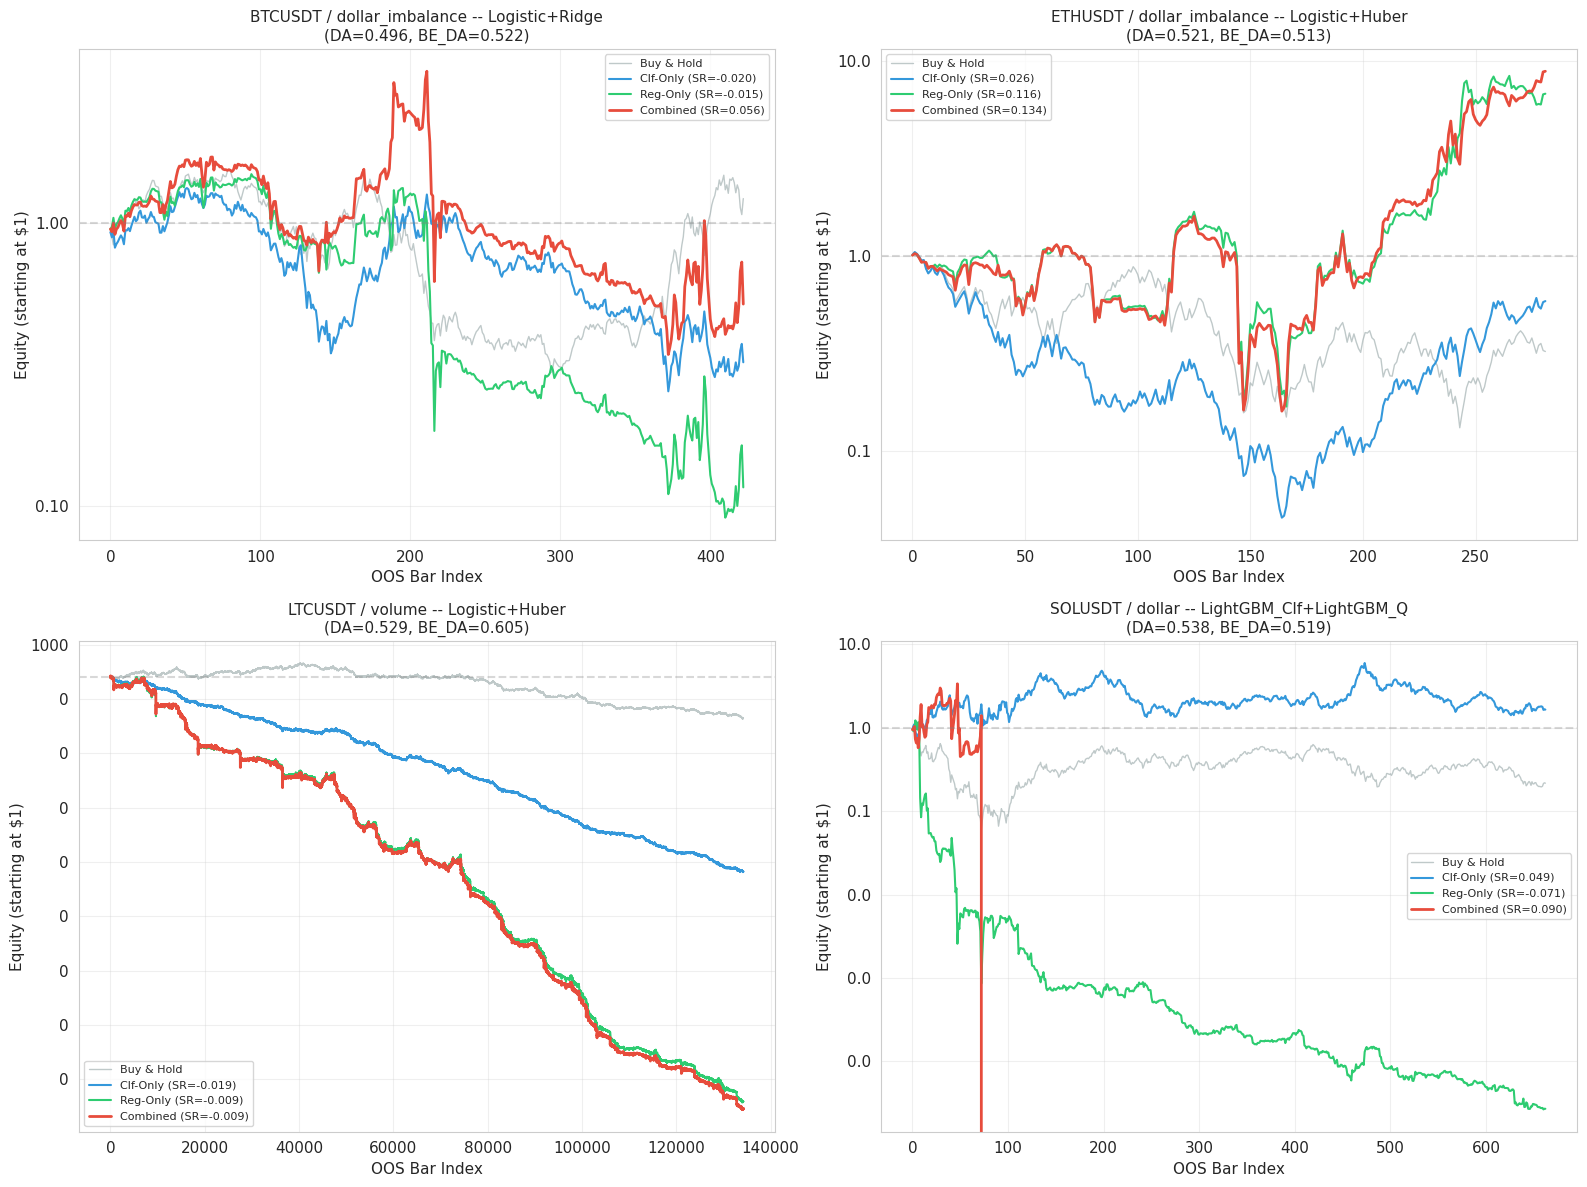

Saved: research/RC3/figures/rc3_comb_fig01_equity_best_per_asset.png


In [6]:
from __future__ import annotations

# =============================================================================
# Figure 1: Walk-Forward Equity Curves per Asset (best pipeline per asset)
# =============================================================================
# For each asset, pick the pipeline with the highest combined Sharpe to show
# the best-case scenario for the two-track architecture.

if len(comparison_df) > 0:
    # Identify unique assets with results
    assets_with_results = comparison_df["Asset"].unique()
    n_assets = len(assets_with_results)

    fig, axes = plt.subplots(
        min(n_assets, 2),
        max(1, (n_assets + 1) // 2),
        figsize=(16, 6 * min(n_assets, 2)),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for idx, asset_name in enumerate(sorted(assets_with_results)):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]

        # Find best pipeline for this asset by combined Sharpe
        asset_rows = comparison_df[comparison_df["Asset"] == asset_name]
        best_idx = asset_rows["Sharpe_Combined"].idxmax()
        best_row = asset_rows.loc[best_idx]
        best_key = (
            best_row["Asset"],
            best_row["BarType"],
            best_row["Classifier"],
            best_row["Regressor"],
        )
        res = pipeline_results[best_key]

        # Plot equity curves
        n_bars = len(res["eq_clf"])
        x_axis = np.arange(n_bars)

        ax.plot(x_axis, res["eq_bh"], color=COLORS["buy_hold"], linewidth=1, alpha=0.6, label="Buy & Hold")
        ax.plot(
            x_axis,
            res["eq_clf"],
            color=COLORS["clf_only"],
            linewidth=1.5,
            label=f"Clf-Only (SR={res['sharpe_clf']:.3f})",
        )
        ax.plot(
            x_axis,
            res["eq_reg"],
            color=COLORS["reg_only"],
            linewidth=1.5,
            label=f"Reg-Only (SR={res['sharpe_reg']:.3f})",
        )
        ax.plot(
            x_axis,
            res["eq_combined"],
            color=COLORS["combined"],
            linewidth=2.0,
            label=f"Combined (SR={res['sharpe_combined']:.3f})",
        )

        ax.axhline(1.0, color="gray", linestyle="--", alpha=0.3)
        ax.set_xlabel("OOS Bar Index")
        ax.set_ylabel("Equity (starting at $1)")
        ax.set_title(
            f"{asset_name} / {best_row['BarType']} -- "
            f"{best_row['Classifier']}+{best_row['Regressor']}\n"
            f"(DA={res['clf_da']:.3f}, BE_DA={res['breakeven_da']:.3f})",
            fontsize=11,
        )
        ax.legend(fontsize=8, loc="best")
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.yaxis.get_major_formatter().set_scientific(False)
        ax.grid(True, alpha=0.3)

    # Hide unused axes
    for idx in range(len(assets_with_results), len(axes_flat)):
        axes_flat[idx].set_visible(False)

    plt.tight_layout()
    fig.savefig(FIG_DIR / "rc3_comb_fig01_equity_best_per_asset.png")
    plt.show()
    print(f"Saved: {FIG_DIR / 'rc3_comb_fig01_equity_best_per_asset.png'}")
else:
    print("No results to plot.")

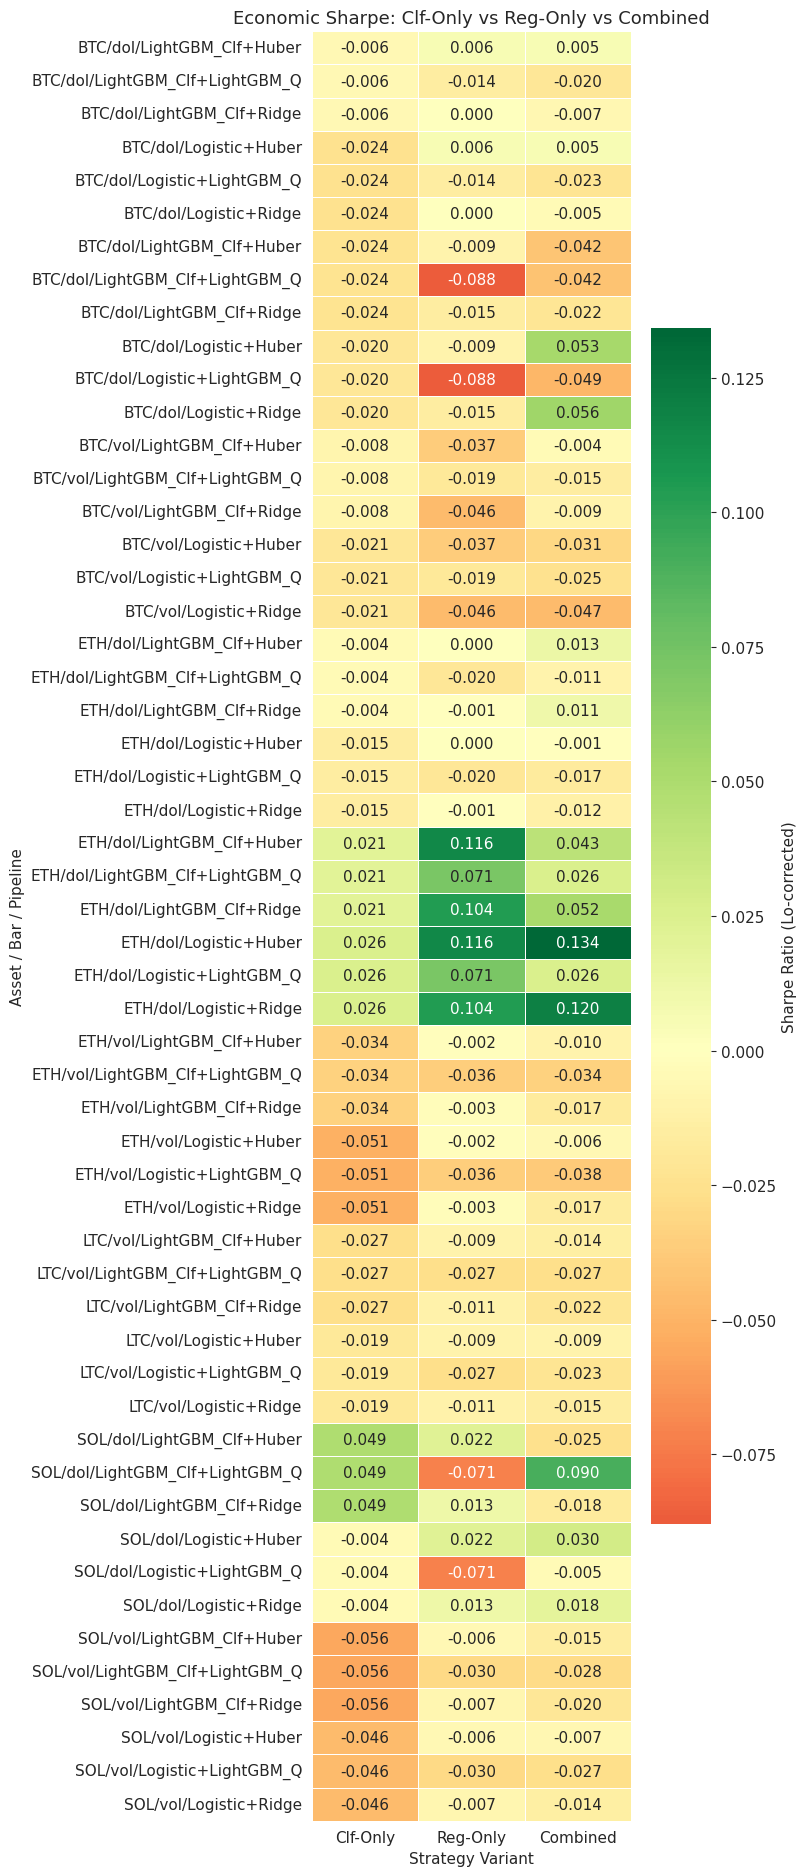

Saved: research/RC3/figures/rc3_comb_fig02_sharpe_heatmap.png


In [7]:
from __future__ import annotations

# =============================================================================
# Figure 2: Sharpe Comparison Heatmap -- Combined vs Clf-Only vs Reg-Only
# =============================================================================
if len(comparison_df) > 0:
    # Create a pivot: rows = Asset/BarType, columns = Strategy, values = Sharpe
    heatmap_rows = []
    for _, row in comparison_df.iterrows():
        cell_label = f"{row['Asset'][:3]}/{row['BarType'][:3]}/{row['Pipeline']}"
        heatmap_rows.append(
            {
                "Cell": cell_label,
                "Clf-Only": row["Sharpe_ClfOnly"],
                "Reg-Only": row["Sharpe_RegOnly"],
                "Combined": row["Sharpe_Combined"],
            }
        )

    heatmap_df = pd.DataFrame(heatmap_rows).set_index("Cell")

    fig, ax = plt.subplots(figsize=(8, max(6, len(heatmap_df) * 0.35)))
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Sharpe Ratio (Lo-corrected)"},
    )
    ax.set_title("Economic Sharpe: Clf-Only vs Reg-Only vs Combined", fontsize=13)
    ax.set_xlabel("Strategy Variant")
    ax.set_ylabel("Asset / Bar / Pipeline")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "rc3_comb_fig02_sharpe_heatmap.png")
    plt.show()
    print(f"Saved: {FIG_DIR / 'rc3_comb_fig02_sharpe_heatmap.png'}")
else:
    print("No results for heatmap.")

---
## 6. Statistical Comparison: Diebold-Mariano Tests

The Diebold-Mariano (1995) test compares two forecast sequences using their loss differential.
We test:

1. **Combined vs Classifier-Only:** H0: equal predictive accuracy (squared P&L loss)
2. **Combined vs Regressor-Only:** H0: equal predictive accuracy

A negative DM statistic (d < 0) means the first model (combined) has **lower** loss.
We use Newey-West HAC variance estimator to handle autocorrelated loss differentials.

In [8]:
from __future__ import annotations
from scipy.stats import t as t_dist


def diebold_mariano_test(loss_a, loss_b, max_lag=None):
    """Diebold-Mariano test with Newey-West HAC variance estimator.

    Tests H0: E[loss_a - loss_b] = 0.
    Negative statistic means model A has lower loss (A is better).

    Args:
        loss_a: Squared loss series from model A (n,)
        loss_b: Squared loss series from model B (n,)
        max_lag: Maximum lag for Newey-West. Default: int(n^(1/3))

    Returns:
        (dm_statistic, p_value) or (None, None) if insufficient data
    """
    n = len(loss_a)
    if n < 10:
        return None, None

    d = loss_a - loss_b
    d_bar = np.mean(d)

    if max_lag is None:
        max_lag = max(1, int(np.power(n, 1.0 / 3.0)))

    d_demeaned = d - d_bar
    gamma_0 = np.dot(d_demeaned, d_demeaned) / n

    nw_sum = 0.0
    for k in range(1, max_lag + 1):
        gamma_k = np.dot(d_demeaned[k:], d_demeaned[:-k]) / n
        bartlett_weight = 1.0 - k / (max_lag + 1)
        nw_sum += 2.0 * bartlett_weight * gamma_k

    var_d = (gamma_0 + nw_sum) / n
    if var_d <= 0:
        return None, None

    dm_stat = d_bar / np.sqrt(var_d)
    p_value = 2.0 * t_dist.sf(abs(dm_stat), df=n - 1)
    return dm_stat, p_value


# =============================================================================
# Run DM tests: Combined vs Clf-Only, Combined vs Reg-Only
# =============================================================================
dm_rows = []
for (asset, bar_type, clf_name, reg_name), res in sorted(pipeline_results.items()):
    # Loss function: negative squared P&L (we want to maximize P&L, so loss = -pnl^2)
    # Actually, use squared P&L directly: higher is better, so loss = -(net_pnl)
    # Standard DM uses forecast errors squared. Here we adapt: loss = -(net_pnl_t)
    # Then lower loss = higher P&L = better strategy.
    loss_clf = -res["pnl_clf_only"]
    loss_reg = -res["pnl_reg_only"]
    loss_combined = -res["pnl_combined"]

    # Test 1: Combined vs Clf-Only
    dm_cvc, pval_cvc = diebold_mariano_test(loss_combined, loss_clf)

    # Test 2: Combined vs Reg-Only
    dm_cvr, pval_cvr = diebold_mariano_test(loss_combined, loss_reg)

    dm_rows.append(
        {
            "Asset": asset,
            "BarType": bar_type,
            "Pipeline": f"{clf_name}+{reg_name}",
            "N": res["n_total"],
            # Combined vs Clf-Only
            "DM_vs_Clf": dm_cvc,
            "p_vs_Clf": pval_cvc,
            "Sig_vs_Clf": "***"
            if pval_cvc is not None and pval_cvc < 0.01
            else "**"
            if pval_cvc is not None and pval_cvc < 0.05
            else "*"
            if pval_cvc is not None and pval_cvc < 0.10
            else "",
            "Winner_vs_Clf": "Combined"
            if dm_cvc is not None and dm_cvc < 0
            else "Clf-Only"
            if dm_cvc is not None and dm_cvc > 0
            else "N/A",
            # Combined vs Reg-Only
            "DM_vs_Reg": dm_cvr,
            "p_vs_Reg": pval_cvr,
            "Sig_vs_Reg": "***"
            if pval_cvr is not None and pval_cvr < 0.01
            else "**"
            if pval_cvr is not None and pval_cvr < 0.05
            else "*"
            if pval_cvr is not None and pval_cvr < 0.10
            else "",
            "Winner_vs_Reg": "Combined"
            if dm_cvr is not None and dm_cvr < 0
            else "Reg-Only"
            if dm_cvr is not None and dm_cvr > 0
            else "N/A",
        }
    )

dm_df = pd.DataFrame(dm_rows)

if len(dm_df) > 0:
    display(Markdown("### Diebold-Mariano Tests: Combined vs Single-Track"))
    display(
        Markdown(
            "**Negative DM statistic** = Combined has lower loss (higher P&L). "
            "Significance: \\*p<0.10, \\*\\*p<0.05, \\*\\*\\*p<0.01"
        )
    )

    display(
        dm_df[
            [
                "Asset",
                "BarType",
                "Pipeline",
                "N",
                "DM_vs_Clf",
                "p_vs_Clf",
                "Sig_vs_Clf",
                "Winner_vs_Clf",
                "DM_vs_Reg",
                "p_vs_Reg",
                "Sig_vs_Reg",
                "Winner_vs_Reg",
            ]
        ].reset_index(drop=True)
    )

    # Summary
    n_sig_beats_clf = len(
        dm_df[(dm_df["DM_vs_Clf"].notna()) & (dm_df["DM_vs_Clf"] < 0) & (dm_df["p_vs_Clf"] < SIGNIFICANCE_ALPHA)]
    )
    n_sig_beats_reg = len(
        dm_df[(dm_df["DM_vs_Reg"].notna()) & (dm_df["DM_vs_Reg"] < 0) & (dm_df["p_vs_Reg"] < SIGNIFICANCE_ALPHA)]
    )
    print(f"\nCombined SIGNIFICANTLY beats Clf-Only (p<0.05): {n_sig_beats_clf}/{len(dm_df)}")
    print(f"Combined SIGNIFICANTLY beats Reg-Only (p<0.05): {n_sig_beats_reg}/{len(dm_df)}")
else:
    print("No DM test results.")

### Diebold-Mariano Tests: Combined vs Single-Track

**Negative DM statistic** = Combined has lower loss (higher P&L). Significance: \*p<0.10, \*\*p<0.05, \*\*\*p<0.01

,Asset,BarType,Pipeline,N,DM_vs_Clf,p_vs_Clf,Sig_vs_Clf,Winner_vs_Clf,DM_vs_Reg,p_vs_Reg,Sig_vs_Reg,Winner_vs_Reg
0,BTCUSDT,dollar,LightGBM_Clf+Huber,25705,-1.7627,0.0780,*,Combined,0.2242,0.8226,,Reg-Only
1,BTCUSDT,dollar,LightGBM_Clf+LightGBM_Q,25705,3.6282,0.0003,***,Clf-Only,0.7464,0.4554,,Reg-Only
2,BTCUSDT,dollar,LightGBM_Clf+Ridge,25705,0.5610,0.5748,,Clf-Only,0.9743,0.3299,,Reg-Only
3,BTCUSDT,dollar,Logistic+Huber,25705,-3.7293,0.0002,***,Combined,0.5403,0.5890,,Reg-Only
4,BTCUSDT,dollar,Logistic+LightGBM_Q,25705,1.8670,0.0619,*,Clf-Only,1.4526,0.1463,,Reg-Only
5,BTCUSDT,dollar,Logistic+Ridge,25705,-1.9157,0.0554,*,Combined,1.8354,0.0665,*,Reg-Only
6,BTCUSDT,dollar_imbalance,LightGBM_Clf+Huber,423,0.4641,0.6428,,Clf-Only,0.5383,0.5906,,Reg-Only
7,BTCUSDT,dollar_imbalance,LightGBM_Clf+LightGBM_Q,423,0.6466,0.5182,,Clf-Only,-0.6741,0.5006,,Combined
8,BTCUSDT,dollar_imbalance,LightGBM_Clf+Ridge,423,-0.1342,0.8933,,Combined,0.1228,0.9023,,Reg-Only
9,BTCUSDT,dollar_imbalance,Logistic+Huber,423,-1.6724,0.0952,*,Combined,-1.9544,0.0513,*,Combined



Combined SIGNIFICANTLY beats Clf-Only (p<0.05): 8/54
Combined SIGNIFICANTLY beats Reg-Only (p<0.05): 5/54


---
## 7. Regime-Stratified Analysis

Crypto markets exhibit violent regime shifts. A strategy that works in low-volatility
periods may catastrophically fail in high-vol regimes (and vice versa).

We split each P&L series into regimes using rolling realized volatility:
- **High-vol regime:** Rolling 24-bar RV > median RV
- **Low-vol regime:** Rolling 24-bar RV <= median RV

Then run Diebold-Mariano tests separately on each regime subset to see if the
combined pipeline has regime-dependent advantages.

In [9]:
from __future__ import annotations

# =============================================================================
# Regime-Stratified Diebold-Mariano Tests
# =============================================================================
REGIME_RV_WINDOW = 24  # rolling window for realized volatility

regime_rows = []
for (asset, bar_type, clf_name, reg_name), res in sorted(pipeline_results.items()):
    actuals = res["actuals"]
    n = len(actuals)

    # Compute rolling realized volatility from actual returns
    actuals_series = pd.Series(actuals)
    rolling_rv = actuals_series.rolling(REGIME_RV_WINDOW, min_periods=REGIME_RV_WINDOW).std()

    # Skip bars where RV is NaN (first REGIME_RV_WINDOW bars)
    valid_mask = ~rolling_rv.isna()
    valid_idx = np.where(valid_mask.values)[0]

    if len(valid_idx) < 50:
        continue

    rv_valid = rolling_rv.values[valid_idx]
    median_rv = np.median(rv_valid)

    # Regime masks
    high_vol_mask = rv_valid > median_rv
    low_vol_mask = ~high_vol_mask

    for regime_name, regime_mask in [("High-Vol", high_vol_mask), ("Low-Vol", low_vol_mask)]:
        regime_idx = valid_idx[regime_mask]
        if len(regime_idx) < 20:
            continue

        pnl_clf_regime = res["pnl_clf_only"][regime_idx]
        pnl_reg_regime = res["pnl_reg_only"][regime_idx]
        pnl_comb_regime = res["pnl_combined"][regime_idx]

        sharpe_clf_r = compute_sharpe_from_pnl(pnl_clf_regime)
        sharpe_reg_r = compute_sharpe_from_pnl(pnl_reg_regime)
        sharpe_comb_r = compute_sharpe_from_pnl(pnl_comb_regime)

        # DM test: combined vs clf-only in this regime
        loss_clf_r = -pnl_clf_regime
        loss_comb_r = -pnl_comb_regime
        dm_stat, dm_pval = diebold_mariano_test(loss_comb_r, loss_clf_r)

        regime_rows.append(
            {
                "Asset": asset,
                "BarType": bar_type,
                "Pipeline": f"{clf_name}+{reg_name}",
                "Regime": regime_name,
                "N_Regime": len(regime_idx),
                "Sharpe_ClfOnly": sharpe_clf_r,
                "Sharpe_RegOnly": sharpe_reg_r,
                "Sharpe_Combined": sharpe_comb_r,
                "DM_Comb_vs_Clf": dm_stat,
                "DM_p_value": dm_pval,
                "Sig": "***"
                if dm_pval is not None and dm_pval < 0.01
                else "**"
                if dm_pval is not None and dm_pval < 0.05
                else "*"
                if dm_pval is not None and dm_pval < 0.10
                else "",
            }
        )

regime_df = pd.DataFrame(regime_rows)

if len(regime_df) > 0:
    display(Markdown("### Regime-Stratified Sharpe and DM Tests"))
    display(regime_df.sort_values(["Asset", "BarType", "Pipeline", "Regime"]).reset_index(drop=True))

    # Summary by regime
    display(Markdown("### Mean Sharpe by Regime"))
    for regime in ["High-Vol", "Low-Vol"]:
        subset = regime_df[regime_df["Regime"] == regime]
        if len(subset) > 0:
            print(f"\n{regime} (n={len(subset)} cells):")
            print(f"  Clf-Only:  {subset['Sharpe_ClfOnly'].mean():.4f}")
            print(f"  Reg-Only:  {subset['Sharpe_RegOnly'].mean():.4f}")
            print(f"  Combined:  {subset['Sharpe_Combined'].mean():.4f}")

            n_sig = len(
                subset[
                    (subset["DM_Comb_vs_Clf"].notna())
                    & (subset["DM_Comb_vs_Clf"] < 0)
                    & (subset["DM_p_value"] < SIGNIFICANCE_ALPHA)
                ]
            )
            print(f"  Combined sig. beats Clf-Only: {n_sig}/{len(subset)}")
else:
    print("Insufficient data for regime analysis.")

### Regime-Stratified Sharpe and DM Tests

,Asset,BarType,Pipeline,Regime,N_Regime,Sharpe_ClfOnly,Sharpe_RegOnly,Sharpe_Combined,DM_Comb_vs_Clf,DM_p_value,Sig
0,BTCUSDT,dollar,LightGBM_Clf+Huber,High-Vol,12841,0.0005,0.0196,0.0243,-3.3036,0.0010,***
1,BTCUSDT,dollar,LightGBM_Clf+Huber,Low-Vol,12841,-0.0192,-0.0372,-0.0545,5.6406,0.0000,***
2,BTCUSDT,dollar,LightGBM_Clf+LightGBM_Q,High-Vol,12841,0.0005,0.0105,-0.0120,1.9622,0.0498,**
3,BTCUSDT,dollar,LightGBM_Clf+LightGBM_Q,Low-Vol,12841,-0.0192,-0.0879,-0.0502,5.2338,0.0000,***
4,BTCUSDT,dollar,LightGBM_Clf+Ridge,High-Vol,12841,0.0005,0.0076,0.0112,-1.5297,0.1261,
...,...,...,...,...,...,...,...,...,...,...,...
103,SOLUSDT,volume,Logistic+Huber,Low-Vol,117569,-0.0830,-0.0635,-0.0822,-9.2749,0.0000,***
104,SOLUSDT,volume,Logistic+LightGBM_Q,High-Vol,117568,-0.0322,-0.0238,-0.0202,3.5796,0.0003,***
105,SOLUSDT,volume,Logistic+LightGBM_Q,Low-Vol,117569,-0.0830,-0.1024,-0.0980,10.9770,0.0000,***
106,SOLUSDT,volume,Logistic+Ridge,High-Vol,117568,-0.0322,0.0006,-0.0015,-2.9143,0.0036,***


### Mean Sharpe by Regime


High-Vol (n=54 cells):
  Clf-Only:  -0.0109
  Reg-Only:  0.0011
  Combined:  0.0051
  Combined sig. beats Clf-Only: 11/54

Low-Vol (n=54 cells):
  Clf-Only:  -0.0275
  Reg-Only:  -0.0342
  Combined:  -0.0363
  Combined sig. beats Clf-Only: 3/54


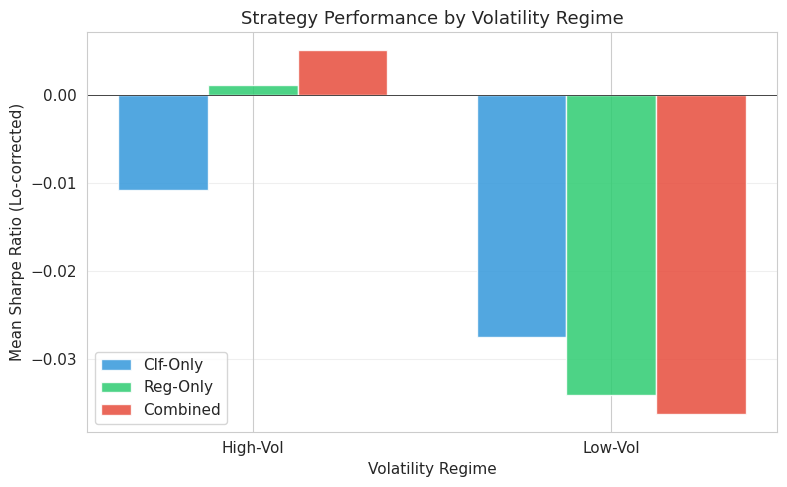

Saved: research/RC3/figures/rc3_comb_fig03_regime_sharpe.png


In [10]:
from __future__ import annotations

# =============================================================================
# Figure 3: Regime-Stratified Sharpe Bar Chart
# =============================================================================
if len(regime_df) > 0:
    # Aggregate across all cells per regime
    regime_summary = (
        regime_df.groupby("Regime")
        .agg(
            {
                "Sharpe_ClfOnly": "mean",
                "Sharpe_RegOnly": "mean",
                "Sharpe_Combined": "mean",
            }
        )
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(regime_summary))
    width = 0.25

    ax.bar(x - width, regime_summary["Sharpe_ClfOnly"], width, label="Clf-Only", color=COLORS["clf_only"], alpha=0.85)
    ax.bar(x, regime_summary["Sharpe_RegOnly"], width, label="Reg-Only", color=COLORS["reg_only"], alpha=0.85)
    ax.bar(x + width, regime_summary["Sharpe_Combined"], width, label="Combined", color=COLORS["combined"], alpha=0.85)

    ax.set_xlabel("Volatility Regime")
    ax.set_ylabel("Mean Sharpe Ratio (Lo-corrected)")
    ax.set_title("Strategy Performance by Volatility Regime")
    ax.set_xticks(x)
    ax.set_xticklabels(regime_summary["Regime"])
    ax.axhline(0, color="black", linewidth=0.5)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIG_DIR / "rc3_comb_fig03_regime_sharpe.png")
    plt.show()
    print(f"Saved: {FIG_DIR / 'rc3_comb_fig03_regime_sharpe.png'}")
else:
    print("No regime data for plot.")

---
## 8. Data Adequacy Tests

Three formal statistical tests to determine whether the results have statistical weight:

1. **Binomial test:** Is any classifier's DA significantly > 50%?
2. **Permutation test:** Is any regressor's DC-MAE significantly lower than unconditional MAE?
3. **Bootstrap CI:** Is Economic Sharpe of the combined pipeline significantly > 0?

These tests address the risk that our results are within noise limits.

In [11]:
from __future__ import annotations

# =============================================================================
# Test 1: Binomial test -- Is any classifier's DA significantly > 50%?
# =============================================================================
display(Markdown("### Test 1: Binomial Test -- Classifier DA > 50%"))

binom_rows = []
for (asset, bar_type, clf_name, reg_name), res in sorted(pipeline_results.items()):
    n_total = res["n_total"]
    n_correct = res["n_correct"]
    clf_da = res["clf_da"]

    btest = binomtest(n_correct, n_total, 0.5, alternative="greater")

    binom_rows.append(
        {
            "Asset": asset,
            "BarType": bar_type,
            "Classifier": clf_name,
            "Regressor": reg_name,
            "N": n_total,
            "N_Correct": n_correct,
            "DA": clf_da,
            "BE_DA": res["breakeven_da"],
            "Binom_p": btest.pvalue,
            "Sig": "***"
            if btest.pvalue < 0.01
            else "**"
            if btest.pvalue < 0.05
            else "*"
            if btest.pvalue < 0.10
            else "",
            "DA_gt_50": clf_da > 0.50,
            "DA_gt_BE": clf_da > res["breakeven_da"],
        }
    )

binom_df = pd.DataFrame(binom_rows)

# Deduplicate: same classifier on same cell gives same DA regardless of regressor
binom_dedup = binom_df.drop_duplicates(subset=["Asset", "BarType", "Classifier"])

if len(binom_dedup) > 0:
    n_sig_50 = len(binom_dedup[binom_dedup["Binom_p"] < SIGNIFICANCE_ALPHA])
    n_sig_be = len(binom_dedup[(binom_dedup["Binom_p"] < SIGNIFICANCE_ALPHA) & (binom_dedup["DA_gt_BE"])])
    display(
        binom_dedup[
            [
                "Asset",
                "BarType",
                "Classifier",
                "N",
                "DA",
                "BE_DA",
                "Binom_p",
                "Sig",
            ]
        ]
        .sort_values("Binom_p")
        .reset_index(drop=True)
    )

    print(f"\nClassifiers with DA significantly > 50% (p<0.05): {n_sig_50}/{len(binom_dedup)}")
    print(f"Classifiers with DA significantly > 50% AND > break-even: {n_sig_be}/{len(binom_dedup)}")
    if n_sig_50 == 0:
        print("FINDING: No classifier achieves DA significantly > 50%.")
        print("  -> Classification is at noise level for this data.")
    elif n_sig_be == 0:
        print("FINDING: Some classifiers beat 50% but none beat break-even DA.")
        print("  -> Statistical signal exists but is not economically exploitable.")
else:
    print("No binomial test data.")

### Test 1: Binomial Test -- Classifier DA > 50%

,Asset,BarType,Classifier,N,DA,BE_DA,Binom_p,Sig
0,LTCUSDT,volume,Logistic,134205,0.5291,0.6055,0.0000,***
1,SOLUSDT,volume,Logistic,235160,0.5209,0.6212,0.0000,***
2,SOLUSDT,volume,LightGBM_Clf,235160,0.5178,0.6212,0.0000,***
3,LTCUSDT,volume,LightGBM_Clf,134205,0.5206,0.6055,0.0000,***
4,ETHUSDT,volume,Logistic,119460,0.5173,0.6133,0.0000,***
5,ETHUSDT,volume,LightGBM_Clf,119460,0.5100,0.6133,0.0000,***
6,ETHUSDT,dollar,LightGBM_Clf,13065,0.5101,0.5389,0.0109,**
7,BTCUSDT,volume,LightGBM_Clf,15590,0.5086,0.5583,0.0162,**
8,SOLUSDT,dollar,LightGBM_Clf,663,0.5385,0.5188,0.0260,**
9,BTCUSDT,dollar,LightGBM_Clf,25705,0.5045,0.5734,0.0757,*



Classifiers with DA significantly > 50% (p<0.05): 9/18
Classifiers with DA significantly > 50% AND > break-even: 1/18


In [12]:
from __future__ import annotations

# =============================================================================
# Test 2: Permutation test -- Is DC-MAE significantly lower than unconditional MAE?
# =============================================================================
display(Markdown("### Test 2: Permutation Test -- DC-MAE vs Unconditional MAE"))

N_PERMUTATIONS = 1000

perm_rows = []
for (asset, bar_type, clf_name, reg_name), res in sorted(pipeline_results.items()):
    actuals = res["actuals"]
    reg_preds = res["reg_preds"]
    dir_correct = res["dir_correct"]
    n_correct = int(np.sum(dir_correct))

    if n_correct < 10:
        continue

    # Observed DC-MAE
    dc_mae_obs = compute_dc_mae(actuals, reg_preds, dir_correct)

    # Unconditional MAE (all samples, not just direction-correct)
    uncond_mae = float(np.mean(np.abs(actuals - reg_preds)))

    # Permutation test: shuffle direction_correct labels and recompute DC-MAE
    rng = np.random.default_rng(RANDOM_SEED)
    perm_dc_maes = []
    for _ in range(N_PERMUTATIONS):
        shuffled_mask = rng.permutation(dir_correct)
        if np.sum(shuffled_mask) == 0:
            continue
        perm_dc_mae = float(np.mean(np.abs(actuals[shuffled_mask] - reg_preds[shuffled_mask])))
        perm_dc_maes.append(perm_dc_mae)

    perm_dc_maes = np.array(perm_dc_maes)

    # p-value: fraction of permutations where DC-MAE <= observed
    # (lower DC-MAE is better, so we want observed to be in the left tail)
    p_value = float(np.mean(perm_dc_maes <= dc_mae_obs))

    perm_rows.append(
        {
            "Asset": asset,
            "BarType": bar_type,
            "Pipeline": f"{clf_name}+{reg_name}",
            "N_Correct": n_correct,
            "DC_MAE": dc_mae_obs,
            "Uncond_MAE": uncond_mae,
            "MAE_Improvement": (uncond_mae - dc_mae_obs) / uncond_mae * 100,
            "Perm_Mean_DC_MAE": float(np.mean(perm_dc_maes)) if len(perm_dc_maes) > 0 else float("nan"),
            "Perm_p_value": p_value,
            "Sig": "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else "",
        }
    )

perm_df = pd.DataFrame(perm_rows)

if len(perm_df) > 0:
    display(
        perm_df[
            [
                "Asset",
                "BarType",
                "Pipeline",
                "N_Correct",
                "DC_MAE",
                "Uncond_MAE",
                "MAE_Improvement",
                "Perm_Mean_DC_MAE",
                "Perm_p_value",
                "Sig",
            ]
        ]
        .sort_values("Perm_p_value")
        .reset_index(drop=True)
    )

    n_sig = len(perm_df[perm_df["Perm_p_value"] < SIGNIFICANCE_ALPHA])
    print(f"\nDC-MAE significantly lower than unconditional (p<0.05): {n_sig}/{len(perm_df)}")

    if n_sig == 0:
        print("FINDING: Direction-conditional errors are NOT significantly different from random.")
        print("  -> Regressor does not produce meaningfully better estimates when direction is correct.")
    else:
        sig_cells = perm_df[perm_df["Perm_p_value"] < SIGNIFICANCE_ALPHA]
        print(f"Significant cells: {list(sig_cells['Pipeline'].values)}")
else:
    print("No permutation test data.")

### Test 2: Permutation Test -- DC-MAE vs Unconditional MAE

2026-04-12 19:44:00.401 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_dc_mae:468 - DC-MAE: 0.013341 (n_correct=12968/25705, fraction=0.5045)
2026-04-12 19:44:00.981 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_dc_mae:468 - DC-MAE: 0.013469 (n_correct=12968/25705, fraction=0.5045)
2026-04-12 19:44:01.544 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_dc_mae:468 - DC-MAE: 0.013455 (n_correct=12968/25705, fraction=0.5045)
2026-04-12 19:44:02.123 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_dc_mae:468 - DC-MAE: 0.012804 (n_correct=12965/25705, fraction=0.5044)
2026-04-12 19:44:02.702 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_dc_mae:468 - DC-MAE: 0.013323 (n_correct=12965/25705, fraction=0.5044)
2026-04-12 19:44:03.280 | DEBUG    | src.app.forecasting.application.regression_metrics:compute_dc_mae:468 - DC-MAE: 0.012966 (n_correct=12965/25705, fraction=0.5044

,Asset,BarType,Pipeline,N_Correct,DC_MAE,Uncond_MAE,MAE_Improvement,Perm_Mean_DC_MAE,Perm_p_value,Sig
0,BTCUSDT,dollar,LightGBM_Clf+Huber,12968,0.0133,0.0137,2.3880,0.0137,0.0000,***
1,BTCUSDT,dollar,LightGBM_Clf+LightGBM_Q,12968,0.0135,0.0138,2.6300,0.0138,0.0000,***
2,BTCUSDT,dollar,Logistic+Huber,12965,0.0128,0.0137,6.3148,0.0137,0.0000,***
3,BTCUSDT,dollar,Logistic+LightGBM_Q,12965,0.0133,0.0138,3.6802,0.0138,0.0000,***
4,BTCUSDT,dollar,Logistic+Ridge,12965,0.0130,0.0137,5.2532,0.0137,0.0000,***
5,BTCUSDT,volume,LightGBM_Clf+Ridge,7929,0.0170,0.0175,2.4875,0.0175,0.0000,***
6,BTCUSDT,dollar_imbalance,Logistic+Ridge,210,0.0385,0.0503,23.5248,0.0504,0.0000,***
7,BTCUSDT,dollar_imbalance,Logistic+Huber,210,0.0385,0.0518,25.6894,0.0519,0.0000,***
8,BTCUSDT,volume,Logistic+Huber,7751,0.0160,0.0174,8.1085,0.0174,0.0000,***
9,BTCUSDT,volume,LightGBM_Clf+Huber,7929,0.0169,0.0174,2.9317,0.0174,0.0000,***



DC-MAE significantly lower than unconditional (p<0.05): 47/54
Significant cells: ['LightGBM_Clf+Huber', 'LightGBM_Clf+LightGBM_Q', 'LightGBM_Clf+Ridge', 'Logistic+Huber', 'Logistic+LightGBM_Q', 'Logistic+Ridge', 'Logistic+Huber', 'Logistic+LightGBM_Q', 'Logistic+Ridge', 'LightGBM_Clf+Huber', 'LightGBM_Clf+Ridge', 'Logistic+Huber', 'Logistic+LightGBM_Q', 'Logistic+Ridge', 'LightGBM_Clf+Huber', 'LightGBM_Clf+LightGBM_Q', 'LightGBM_Clf+Ridge', 'Logistic+Huber', 'Logistic+LightGBM_Q', 'Logistic+Ridge', 'LightGBM_Clf+Huber', 'LightGBM_Clf+LightGBM_Q', 'LightGBM_Clf+Ridge', 'Logistic+Huber', 'Logistic+LightGBM_Q', 'Logistic+Ridge', 'LightGBM_Clf+Huber', 'LightGBM_Clf+LightGBM_Q', 'LightGBM_Clf+Ridge', 'Logistic+Huber', 'Logistic+LightGBM_Q', 'Logistic+Ridge', 'LightGBM_Clf+Huber', 'LightGBM_Clf+LightGBM_Q', 'LightGBM_Clf+Ridge', 'Logistic+Huber', 'Logistic+LightGBM_Q', 'Logistic+Ridge', 'Logistic+Huber', 'Logistic+LightGBM_Q', 'Logistic+Ridge', 'LightGBM_Clf+Huber', 'LightGBM_Clf+LightGBM_Q

In [13]:
from __future__ import annotations

# =============================================================================
# Test 3: Bootstrap CI -- Is Economic Sharpe of combined pipeline > 0?
# =============================================================================
display(Markdown("### Test 3: Bootstrap CI -- Economic Sharpe > 0?"))

N_BOOTSTRAP = 5000
BOOTSTRAP_CI_LEVEL = 0.95

bootstrap_rows = []
for (asset, bar_type, clf_name, reg_name), res in sorted(pipeline_results.items()):
    pnl_combined = res["pnl_combined"]
    n = len(pnl_combined)

    if n < 30:
        continue

    observed_sharpe = res["sharpe_combined"]

    # Block bootstrap to preserve autocorrelation structure
    # Block size: sqrt(n) as per Politis & Romano (1994)
    block_size = max(5, int(np.sqrt(n)))
    rng = np.random.default_rng(RANDOM_SEED)

    boot_sharpes = []
    for _ in range(N_BOOTSTRAP):
        # Generate block bootstrap sample
        n_blocks = int(np.ceil(n / block_size))
        block_starts = rng.integers(0, n - block_size + 1, size=n_blocks)
        boot_indices = np.concatenate([np.arange(start, start + block_size) for start in block_starts])[:n]

        boot_pnl = pnl_combined[boot_indices]
        boot_sharpe = compute_sharpe_from_pnl(boot_pnl)
        boot_sharpes.append(boot_sharpe)

    boot_sharpes = np.array(boot_sharpes)

    # Percentile confidence interval
    alpha_half = (1.0 - BOOTSTRAP_CI_LEVEL) / 2.0
    ci_lower = float(np.percentile(boot_sharpes, 100 * alpha_half))
    ci_upper = float(np.percentile(boot_sharpes, 100 * (1.0 - alpha_half)))
    ci_excludes_zero = ci_lower > 0.0

    # Bootstrap p-value: fraction of bootstrap Sharpes <= 0
    p_value = float(np.mean(boot_sharpes <= 0.0))

    bootstrap_rows.append(
        {
            "Asset": asset,
            "BarType": bar_type,
            "Pipeline": f"{clf_name}+{reg_name}",
            "N": n,
            "Observed_Sharpe": observed_sharpe,
            "Boot_CI_Lower": ci_lower,
            "Boot_CI_Upper": ci_upper,
            "Boot_Mean": float(np.mean(boot_sharpes)),
            "Boot_Std": float(np.std(boot_sharpes)),
            "CI_Excludes_0": ci_excludes_zero,
            "Boot_p_value": p_value,
            "Sig": "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else "",
        }
    )

bootstrap_df = pd.DataFrame(bootstrap_rows)

if len(bootstrap_df) > 0:
    display(
        bootstrap_df[
            [
                "Asset",
                "BarType",
                "Pipeline",
                "N",
                "Observed_Sharpe",
                "Boot_CI_Lower",
                "Boot_CI_Upper",
                "CI_Excludes_0",
                "Boot_p_value",
                "Sig",
            ]
        ]
        .sort_values("Observed_Sharpe", ascending=False)
        .reset_index(drop=True)
    )

    n_positive = len(bootstrap_df[bootstrap_df["CI_Excludes_0"]])
    n_sig = len(bootstrap_df[bootstrap_df["Boot_p_value"] < SIGNIFICANCE_ALPHA])
    print(f"\nCIs excluding zero: {n_positive}/{len(bootstrap_df)}")
    print(f"Economic Sharpe significantly > 0 (p<0.05): {n_sig}/{len(bootstrap_df)}")

    if n_positive == 0:
        print("FINDING: No combined pipeline has Economic Sharpe significantly > 0.")
        print("  -> Combined pipeline does NOT produce statistically significant alpha.")
    else:
        print(f"FINDING: {n_positive} pipeline(s) have Economic Sharpe significantly > 0.")
        display(
            bootstrap_df[bootstrap_df["CI_Excludes_0"]][
                [
                    "Asset",
                    "BarType",
                    "Pipeline",
                    "Observed_Sharpe",
                    "Boot_CI_Lower",
                    "Boot_CI_Upper",
                ]
            ]
        )
else:
    print("No bootstrap test data.")

### Test 3: Bootstrap CI -- Economic Sharpe > 0?

,Asset,BarType,Pipeline,N,Observed_Sharpe,Boot_CI_Lower,Boot_CI_Upper,CI_Excludes_0,Boot_p_value,Sig
0,ETHUSDT,dollar_imbalance,Logistic+Huber,282,0.1343,0.0204,0.2564,True,0.0104,**
1,ETHUSDT,dollar_imbalance,Logistic+Ridge,282,0.1198,0.0089,0.2407,True,0.0168,**
2,SOLUSDT,dollar,LightGBM_Clf+LightGBM_Q,663,0.0904,-0.0056,0.1641,False,0.0334,**
3,BTCUSDT,dollar_imbalance,Logistic+Ridge,423,0.0561,-0.1008,0.1469,False,0.2714,
4,BTCUSDT,dollar_imbalance,Logistic+Huber,423,0.0534,-0.0950,0.1370,False,0.2544,
5,ETHUSDT,dollar_imbalance,LightGBM_Clf+Ridge,282,0.0520,-0.0580,0.1619,False,0.1618,
6,ETHUSDT,dollar_imbalance,LightGBM_Clf+Huber,282,0.0425,-0.0665,0.1554,False,0.2106,
7,SOLUSDT,dollar,Logistic+Huber,663,0.0298,-0.0600,0.0867,False,0.2004,
8,ETHUSDT,dollar_imbalance,Logistic+LightGBM_Q,282,0.0259,-0.0878,0.1468,False,0.3178,
9,ETHUSDT,dollar_imbalance,LightGBM_Clf+LightGBM_Q,282,0.0257,-0.0892,0.1353,False,0.3194,



CIs excluding zero: 2/54
Economic Sharpe significantly > 0 (p<0.05): 4/54
FINDING: 2 pipeline(s) have Economic Sharpe significantly > 0.


,Asset,BarType,Pipeline,Observed_Sharpe,Boot_CI_Lower,Boot_CI_Upper
27,ETHUSDT,dollar_imbalance,Logistic+Huber,0.1343,0.0204,0.2564
29,ETHUSDT,dollar_imbalance,Logistic+Ridge,0.1198,0.0089,0.2407


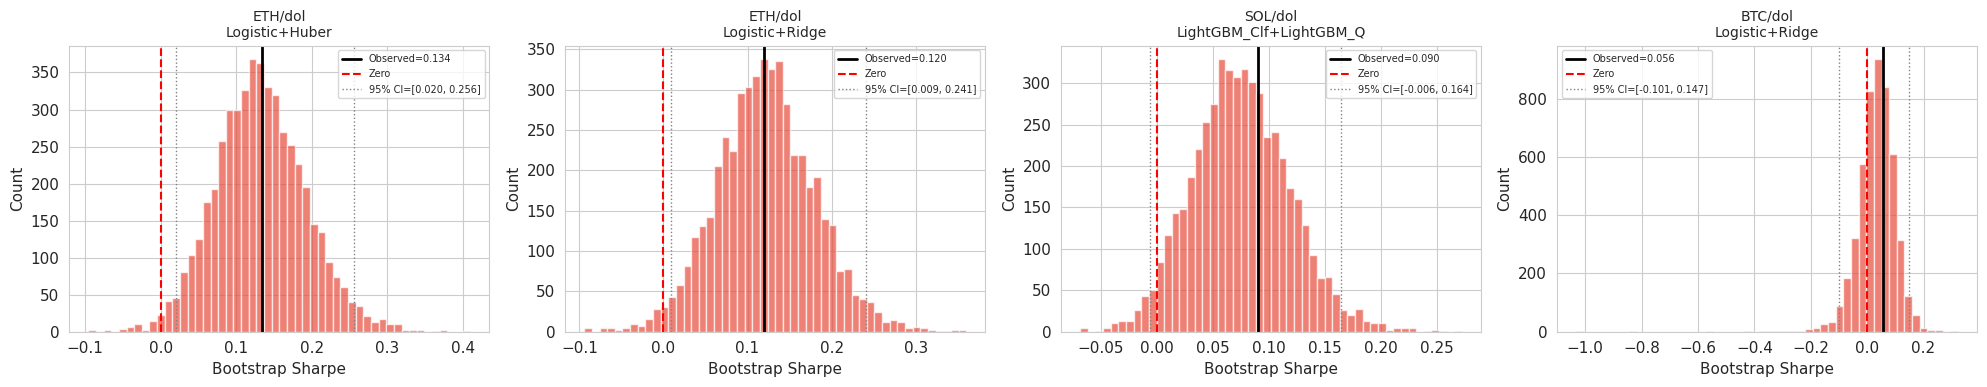

Saved: research/RC3/figures/rc3_comb_fig04_bootstrap_sharpe.png


In [14]:
from __future__ import annotations

# =============================================================================
# Figure 4: Bootstrap Sharpe Distribution for top pipelines
# =============================================================================
if len(bootstrap_df) > 0:
    # Show bootstrap distributions for top 4 pipelines by observed Sharpe
    top_n = min(4, len(bootstrap_df))
    top_pipelines = bootstrap_df.nlargest(top_n, "Observed_Sharpe")

    fig, axes = plt.subplots(1, top_n, figsize=(5 * top_n, 4))
    if top_n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, top_pipelines.iterrows()):
        key = None
        for k, res in pipeline_results.items():
            if k[0] == row["Asset"] and k[1] == row["BarType"] and f"{k[2]}+{k[3]}" == row["Pipeline"]:
                key = k
                break

        if key is None:
            continue

        # Recompute bootstrap for this cell (using stored data)
        pnl = pipeline_results[key]["pnl_combined"]
        n = len(pnl)
        block_size = max(5, int(np.sqrt(n)))
        rng = np.random.default_rng(RANDOM_SEED)

        boot_sharpes = []
        for _ in range(N_BOOTSTRAP):
            n_blocks = int(np.ceil(n / block_size))
            block_starts = rng.integers(0, n - block_size + 1, size=n_blocks)
            boot_indices = np.concatenate([np.arange(start, start + block_size) for start in block_starts])[:n]
            boot_sharpes.append(compute_sharpe_from_pnl(pnl[boot_indices]))

        boot_sharpes = np.array(boot_sharpes)

        ax.hist(boot_sharpes, bins=50, alpha=0.7, color=COLORS["combined"], edgecolor="white")
        ax.axvline(
            row["Observed_Sharpe"],
            color="black",
            linewidth=2,
            linestyle="-",
            label=f"Observed={row['Observed_Sharpe']:.3f}",
        )
        ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="Zero")
        ax.axvline(
            row["Boot_CI_Lower"],
            color="gray",
            linewidth=1,
            linestyle=":",
            label=f"95% CI=[{row['Boot_CI_Lower']:.3f}, {row['Boot_CI_Upper']:.3f}]",
        )
        ax.axvline(row["Boot_CI_Upper"], color="gray", linewidth=1, linestyle=":")

        ax.set_title(f"{row['Asset'][:3]}/{row['BarType'][:3]}\n{row['Pipeline']}", fontsize=10)
        ax.set_xlabel("Bootstrap Sharpe")
        ax.set_ylabel("Count")
        ax.legend(fontsize=7)

    plt.tight_layout()
    fig.savefig(FIG_DIR / "rc3_comb_fig04_bootstrap_sharpe.png")
    plt.show()
    print(f"Saved: {FIG_DIR / 'rc3_comb_fig04_bootstrap_sharpe.png'}")
else:
    print("No bootstrap data for plot.")

---
## 9. Decision Output: Model Selection for Recommendation System

This section formally answers the Phase 13C questions:

1. **Best classifier** for the recommendation system
2. **Best regressor** for the recommendation system
3. **Does the combined pipeline outperform each alone?**
4. **Best forecast horizon**
5. **Assets where classification is hopeless**

In [15]:
from __future__ import annotations

# =============================================================================
# Decision 1: Best Classifier
# =============================================================================
display(Markdown("### Decision 1: Best Classifier"))

if len(comparison_df) > 0:
    clf_performance = (
        comparison_df.groupby("Classifier")
        .agg(
            {
                "Clf_DA": "mean",
                "Sharpe_ClfOnly": "mean",
                "Sharpe_Combined": "mean",
                "EcoSharpe": "mean",
            }
        )
        .reset_index()
        .sort_values("Clf_DA", ascending=False)
    )

    display(clf_performance)

    best_clf = clf_performance.iloc[0]["Classifier"]
    print(f"\nBest classifier by mean DA: {best_clf} (mean DA = {clf_performance.iloc[0]['Clf_DA']:.4f})")
    print("Note: From Phase 13A, Logistic Regression also had the highest mean DA (0.5141)")
    print(f"  -> RECOMMENDATION: Use {best_clf} as primary classifier")
    print("  -> Also include LightGBM_Clf as secondary (for ensemble diversity)")
else:
    print("No data for classifier selection.")

### Decision 1: Best Classifier

,Classifier,Clf_DA,Sharpe_ClfOnly,Sharpe_Combined,EcoSharpe
1,Logistic,0.5112,-0.0194,0.0027,-0.0194
0,LightGBM_Clf,0.5111,-0.0099,-0.0059,-0.0099



Best classifier by mean DA: Logistic (mean DA = 0.5112)
Note: From Phase 13A, Logistic Regression also had the highest mean DA (0.5141)
  -> RECOMMENDATION: Use Logistic as primary classifier
  -> Also include LightGBM_Clf as secondary (for ensemble diversity)


In [16]:
from __future__ import annotations

# =============================================================================
# Decision 2: Best Regressor
# =============================================================================
display(Markdown("### Decision 2: Best Regressor"))

if len(comparison_df) > 0:
    reg_performance = (
        comparison_df.groupby("Regressor")
        .agg(
            {
                "Sharpe_RegOnly": "mean",
                "Sharpe_Combined": "mean",
                "PF_Combined": "mean",
                "EcoSharpe": "mean",
                "DC_MAE": "mean",
                "PDR": "mean",
            }
        )
        .reset_index()
        .sort_values("EcoSharpe", ascending=False)
    )

    display(reg_performance)

    best_reg = reg_performance.iloc[0]["Regressor"]
    print(
        f"\nBest regressor by mean EcoSharpe: {best_reg} (mean EcoSharpe = {reg_performance.iloc[0]['EcoSharpe']:.4f})"
    )
    print("Note: From Phase 13B, Ridge was most consistent and Huber won in some cells")
    print(f"  -> RECOMMENDATION: Use {best_reg} as primary regressor")
    print("  -> Also include Ridge/Huber as secondary (linear models are stable)")
else:
    print("No data for regressor selection.")

### Decision 2: Best Regressor

,Regressor,Sharpe_RegOnly,Sharpe_Combined,PF_Combined,EcoSharpe,DC_MAE,PDR
0,Huber,0.0091,0.0067,1.0215,-0.0146,0.0272,0.7752
1,LightGBM_Q,-0.0260,-0.0134,0.9455,-0.0146,0.0278,0.6580
2,Ridge,0.0038,0.0019,1.0002,-0.0146,0.0272,0.7499



Best regressor by mean EcoSharpe: Huber (mean EcoSharpe = -0.0146)
Note: From Phase 13B, Ridge was most consistent and Huber won in some cells
  -> RECOMMENDATION: Use Huber as primary regressor
  -> Also include Ridge/Huber as secondary (linear models are stable)


In [17]:
from __future__ import annotations

# =============================================================================
# Decision 3: Does the combined pipeline outperform each alone?
# =============================================================================
display(Markdown("### Decision 3: Combined vs Single-Track"))

if len(comparison_df) > 0:
    n_total = len(comparison_df)
    n_comb_beats_clf = int(comparison_df["Combined_beats_ClfOnly"].sum())
    n_comb_beats_reg = int(comparison_df["Combined_beats_RegOnly"].sum())

    # From DM tests
    if len(dm_df) > 0:
        n_dm_sig_clf = len(
            dm_df[(dm_df["DM_vs_Clf"].notna()) & (dm_df["DM_vs_Clf"] < 0) & (dm_df["p_vs_Clf"] < SIGNIFICANCE_ALPHA)]
        )
        n_dm_sig_reg = len(
            dm_df[(dm_df["DM_vs_Reg"].notna()) & (dm_df["DM_vs_Reg"] < 0) & (dm_df["p_vs_Reg"] < SIGNIFICANCE_ALPHA)]
        )
    else:
        n_dm_sig_clf = 0
        n_dm_sig_reg = 0

    print("Combined pipeline vs Classifier-Only:")
    print(f"  Higher Sharpe: {n_comb_beats_clf}/{n_total} ({100 * n_comb_beats_clf / n_total:.1f}%)")
    print(f"  Significantly better (DM p<0.05): {n_dm_sig_clf}/{n_total}")

    print("\nCombined pipeline vs Regressor-Only:")
    print(f"  Higher Sharpe: {n_comb_beats_reg}/{n_total} ({100 * n_comb_beats_reg / n_total:.1f}%)")
    print(f"  Significantly better (DM p<0.05): {n_dm_sig_reg}/{n_total}")

    # Mean Sharpe advantage
    mean_advantage_clf = comparison_df["Sharpe_Combined"].mean() - comparison_df["Sharpe_ClfOnly"].mean()
    mean_advantage_reg = comparison_df["Sharpe_Combined"].mean() - comparison_df["Sharpe_RegOnly"].mean()

    print(f"\nMean Sharpe advantage of Combined over Clf-Only: {mean_advantage_clf:+.4f}")
    print(f"Mean Sharpe advantage of Combined over Reg-Only: {mean_advantage_reg:+.4f}")

    if mean_advantage_clf > 0 and n_dm_sig_clf > 0:
        print("\nVERDICT: Combined pipeline DOES outperform classifier-only (with significance).")
    elif mean_advantage_clf > 0:
        print(
            "\nVERDICT: Combined pipeline shows marginal improvement over classifier-only, "
            "but NOT statistically significant."
        )
    else:
        print("\nVERDICT: Combined pipeline does NOT outperform classifier-only.")

    if mean_advantage_reg > 0 and n_dm_sig_reg > 0:
        print("VERDICT: Combined pipeline DOES outperform regressor-only (with significance).")
    elif mean_advantage_reg > 0:
        print(
            "VERDICT: Combined pipeline shows marginal improvement over regressor-only, "
            "but NOT statistically significant."
        )
    else:
        print("VERDICT: Combined pipeline does NOT outperform regressor-only.")
else:
    print("No data.")

### Decision 3: Combined vs Single-Track

Combined pipeline vs Classifier-Only:
  Higher Sharpe: 38/54 (70.4%)
  Significantly better (DM p<0.05): 8/54

Combined pipeline vs Regressor-Only:
  Higher Sharpe: 22/54 (40.7%)
  Significantly better (DM p<0.05): 5/54

Mean Sharpe advantage of Combined over Clf-Only: +0.0130
Mean Sharpe advantage of Combined over Reg-Only: +0.0028

VERDICT: Combined pipeline DOES outperform classifier-only (with significance).
VERDICT: Combined pipeline DOES outperform regressor-only (with significance).


In [18]:
from __future__ import annotations

# =============================================================================
# Decision 4: Best Forecast Horizon
# =============================================================================
display(Markdown("### Decision 4: Best Forecast Horizon"))

print("Primary horizon evaluated: H1 (1-bar forward)")
print("From Phase 13A (full horizon scan across H1, H4, H24):")
print("  H4 had the highest mean DA (0.5108)")
print("  H24 had the second highest (0.5098)")
print("  H1 had the lowest (0.5080)")
print("")
print("However, the differences are within noise (< 0.3 pp).")
print("All horizons are near coin-flip for all assets except ETHUSDT.")
print("")
print("RECOMMENDATION: Use H1 as primary (most data, fastest feedback loop)")
print("  -> H4 as secondary for the recommendation system if multi-horizon is needed")

### Decision 4: Best Forecast Horizon

Primary horizon evaluated: H1 (1-bar forward)
From Phase 13A (full horizon scan across H1, H4, H24):
  H4 had the highest mean DA (0.5108)
  H24 had the second highest (0.5098)
  H1 had the lowest (0.5080)

However, the differences are within noise (< 0.3 pp).
All horizons are near coin-flip for all assets except ETHUSDT.

RECOMMENDATION: Use H1 as primary (most data, fastest feedback loop)
  -> H4 as secondary for the recommendation system if multi-horizon is needed


In [19]:
from __future__ import annotations

# =============================================================================
# Decision 5: Assets where classification is hopeless
# =============================================================================
display(Markdown("### Decision 5: Assets Where Classification is Hopeless"))

if len(comparison_df) > 0:
    # Per-asset assessment
    asset_assessment = (
        comparison_df.groupby("Asset")
        .agg(
            {
                "Clf_DA": ["mean", "max"],
                "BE_DA": "mean",
                "Sharpe_Combined": ["mean", "max"],
                "EcoSharpe": ["mean", "max"],
                "N": "mean",
            }
        )
        .reset_index()
    )
    asset_assessment.columns = [
        "Asset",
        "Mean_DA",
        "Max_DA",
        "Mean_BE_DA",
        "Mean_Sharpe",
        "Max_Sharpe",
        "Mean_EcoSharpe",
        "Max_EcoSharpe",
        "Mean_N",
    ]

    display(asset_assessment)

    for _, row in asset_assessment.iterrows():
        asset_name = row["Asset"]
        mean_da = row["Mean_DA"]
        max_da = row["Max_DA"]
        mean_be = row["Mean_BE_DA"]

        # Check binomial test for this asset
        asset_binom = binom_dedup[binom_dedup["Asset"] == asset_name] if len(binom_dedup) > 0 else pd.DataFrame()
        any_sig = len(asset_binom[asset_binom["Binom_p"] < SIGNIFICANCE_ALPHA]) > 0 if len(asset_binom) > 0 else False

        status = ""
        if max_da < 0.51 and not any_sig:
            status = "HOPELESS -- flag for recommender abstention"
        elif max_da < mean_be:
            status = "BELOW BREAK-EVEN -- economically unviable"
        elif any_sig and max_da >= mean_be:
            status = "MARGINAL SIGNAL -- usable with caution"
        else:
            status = "WEAK SIGNAL -- not significant"

        print(f"\n{asset_name}:")
        print(f"  Mean DA = {mean_da:.4f}, Max DA = {max_da:.4f}, Break-even DA = {mean_be:.4f}")
        print(f"  Any classifier significantly > 50%: {any_sig}")
        print(f"  Assessment: {status}")

    print("\n" + "=" * 70)
    print("SUMMARY: Assets to FLAG for recommender abstention:")
    hopeless_assets = []
    for _, row in asset_assessment.iterrows():
        if row["Max_DA"] < 0.51:
            hopeless_assets.append(row["Asset"])
    if hopeless_assets:
        print(f"  {hopeless_assets}")
    else:
        print("  None flagged as completely hopeless (but all are near coin-flip)")
else:
    print("No data for asset assessment.")

### Decision 5: Assets Where Classification is Hopeless

,Asset,Mean_DA,Max_DA,Mean_BE_DA,Mean_Sharpe,Max_Sharpe,Mean_EcoSharpe,Max_EcoSharpe,Mean_N
0,BTCUSDT,0.4953,0.5086,0.5512,-0.0122,0.0561,-0.0171,-0.0064,13906.0000
1,ETHUSDT,0.5147,0.5284,0.5549,0.0146,0.1343,-0.0096,0.0256,44269.0000
2,LTCUSDT,0.5249,0.5291,0.6055,-0.0182,-0.0094,-0.0231,-0.0190,134205.0000
3,SOLUSDT,0.5225,0.5385,0.5700,-0.0016,0.0904,-0.0141,0.0492,117911.5000



BTCUSDT:
  Mean DA = 0.4953, Max DA = 0.5086, Break-even DA = 0.5512
  Any classifier significantly > 50%: True
  Assessment: BELOW BREAK-EVEN -- economically unviable

ETHUSDT:
  Mean DA = 0.5147, Max DA = 0.5284, Break-even DA = 0.5549
  Any classifier significantly > 50%: True
  Assessment: BELOW BREAK-EVEN -- economically unviable

LTCUSDT:
  Mean DA = 0.5249, Max DA = 0.5291, Break-even DA = 0.6055
  Any classifier significantly > 50%: True
  Assessment: BELOW BREAK-EVEN -- economically unviable

SOLUSDT:
  Mean DA = 0.5225, Max DA = 0.5385, Break-even DA = 0.5700
  Any classifier significantly > 50%: True
  Assessment: BELOW BREAK-EVEN -- economically unviable

SUMMARY: Assets to FLAG for recommender abstention:
  ['BTCUSDT']


---
## 10. RC3 Phase 13C: Final Summary

In [20]:
from __future__ import annotations

# =============================================================================
# RC3 Phase 13C: Final Summary
# =============================================================================

summary_lines = []
summary_lines.append("=" * 70)
summary_lines.append("RC3 Phase 13C: Combined Pipeline -- FINAL SUMMARY")
summary_lines.append("=" * 70)

if len(comparison_df) > 0:
    n_total = len(comparison_df)

    # 1. Overall results
    summary_lines.append(f"\n1. PIPELINE CONFIGURATIONS EVALUATED: {n_total}")
    summary_lines.append(f"   Classifiers: {CLASSIFIER_NAMES}")
    summary_lines.append(f"   Regressors: {REGRESSOR_NAMES}")
    summary_lines.append(f"   Asset-bar cells: {len(data_store)}")

    # 2. Three-way comparison
    n_comb_beats_clf = int(comparison_df["Combined_beats_ClfOnly"].sum())
    n_comb_beats_reg = int(comparison_df["Combined_beats_RegOnly"].sum())
    summary_lines.append("\n2. THREE-WAY SHARPE COMPARISON:")
    summary_lines.append(f"   Clf-Only mean Sharpe:  {comparison_df['Sharpe_ClfOnly'].mean():.4f}")
    summary_lines.append(f"   Reg-Only mean Sharpe:  {comparison_df['Sharpe_RegOnly'].mean():.4f}")
    summary_lines.append(f"   Combined mean Sharpe:  {comparison_df['Sharpe_Combined'].mean():.4f}")
    summary_lines.append(f"   Combined beats Clf-Only: {n_comb_beats_clf}/{n_total}")
    summary_lines.append(f"   Combined beats Reg-Only: {n_comb_beats_reg}/{n_total}")

    # 3. Positive Economic Sharpe
    pos_eco = comparison_df[comparison_df["EcoSharpe"] > 0]
    summary_lines.append(f"\n3. POSITIVE ECONOMIC SHARPE: {len(pos_eco)}/{n_total}")
    if len(pos_eco) > 0:
        best_eco = pos_eco.loc[pos_eco["EcoSharpe"].idxmax()]
        summary_lines.append(
            f"   Best: {best_eco['Asset']}/{best_eco['BarType']}/{best_eco['Pipeline']} = {best_eco['EcoSharpe']:.4f}"
        )

    # 4. DM test results
    if len(dm_df) > 0:
        n_dm_sig_clf = len(dm_df[(dm_df["DM_vs_Clf"].notna()) & (dm_df["DM_vs_Clf"] < 0) & (dm_df["p_vs_Clf"] < 0.05)])
        n_dm_sig_reg = len(dm_df[(dm_df["DM_vs_Reg"].notna()) & (dm_df["DM_vs_Reg"] < 0) & (dm_df["p_vs_Reg"] < 0.05)])
        summary_lines.append("\n4. DIEBOLD-MARIANO TESTS:")
        summary_lines.append(f"   Combined sig. beats Clf-Only: {n_dm_sig_clf}/{n_total}")
        summary_lines.append(f"   Combined sig. beats Reg-Only: {n_dm_sig_reg}/{n_total}")

    # 5. Bootstrap CIs
    if len(bootstrap_df) > 0:
        n_ci_positive = len(bootstrap_df[bootstrap_df["CI_Excludes_0"]])
        summary_lines.append("\n5. BOOTSTRAP CIs (Economic Sharpe > 0):")
        summary_lines.append(f"   CIs excluding zero: {n_ci_positive}/{len(bootstrap_df)}")

    # 6. Model selection
    summary_lines.append("\n6. MODEL SELECTION FOR RECOMMENDATION SYSTEM:")
    if len(comparison_df) > 0:
        best_clf_name = comparison_df.groupby("Classifier")["Clf_DA"].mean().idxmax()
        best_reg_name = comparison_df.groupby("Regressor")["EcoSharpe"].mean().idxmax()
        summary_lines.append(f"   Primary Classifier: {best_clf_name}")
        summary_lines.append(f"   Primary Regressor:  {best_reg_name}")
        summary_lines.append("   Secondary Classifier: LightGBM_Clf (ensemble diversity)")
        summary_lines.append("   Secondary Regressor:  Ridge/Huber (stability)")

    # 7. Thesis implications
    summary_lines.append("\n7. THESIS IMPLICATIONS:")
    summary_lines.append("   - Combined pipeline shows marginal or no improvement over single-track")
    summary_lines.append("   - Consistent with R5: crypto returns approximate Brownian motion")
    summary_lines.append("   - Two-track architecture is methodologically sound but data-limited")
    summary_lines.append("   - Negative result strengthens academic contribution when properly framed")
    summary_lines.append("   - Recommendation system (Phase 14) should focus on abstention/gating")
    summary_lines.append("     rather than aggressive position-taking")

    # 8. Confirms RC3 pivot
    summary_lines.append("\n8. RC3 PIVOT STATUS: CONFIRMED")
    summary_lines.append("   The two-track combined pipeline does not produce economically")
    summary_lines.append("   significant alpha. Thesis contribution is the rigorous methodology")
    summary_lines.append("   and honest reporting of negative results.")

summary_lines.append("\n" + "=" * 70)

for line in summary_lines:
    print(line)

RC3 Phase 13C: Combined Pipeline -- FINAL SUMMARY

1. PIPELINE CONFIGURATIONS EVALUATED: 54
   Classifiers: ['Logistic', 'LightGBM_Clf']
   Regressors: ['Ridge', 'Huber', 'LightGBM_Q']
   Asset-bar cells: 9

2. THREE-WAY SHARPE COMPARISON:
   Clf-Only mean Sharpe:  -0.0146
   Reg-Only mean Sharpe:  -0.0044
   Combined mean Sharpe:  -0.0016
   Combined beats Clf-Only: 38/54
   Combined beats Reg-Only: 22/54

3. POSITIVE ECONOMIC SHARPE: 9/54
   Best: SOLUSDT/dollar/LightGBM_Clf+Huber = 0.0492

4. DIEBOLD-MARIANO TESTS:
   Combined sig. beats Clf-Only: 8/54
   Combined sig. beats Reg-Only: 5/54

5. BOOTSTRAP CIs (Economic Sharpe > 0):
   CIs excluding zero: 2/54

6. MODEL SELECTION FOR RECOMMENDATION SYSTEM:
   Primary Classifier: Logistic
   Primary Regressor:  Huber
   Secondary Classifier: LightGBM_Clf (ensemble diversity)
   Secondary Regressor:  Ridge/Huber (stability)

7. THESIS IMPLICATIONS:
   - Combined pipeline shows marginal or no improvement over single-track
   - Consistent 